# **프로젝트: 자율주행 보조 시스템 (Self-Drive Assist) 만들기**

#### **1. 프로젝트 목적:**
RetinaNet 기반 객체 탐지 모델을 KITTI 데이터셋으로 학습시켜, 실시간 도로 상황에서 보행자 또는 차량을 탐지하고 정지/주행 여부를 자동으로 판단하는 자율주행 보조 시스템을 구현한다. 
탐지 결과를 바운딩 박스와 클래스 레이블로 시각화하고 Stop/Go 판단 정확도로 성능을 정량 평가한다.  

#### **2. 데이터셋: [KITTI Object Detection](https://www.cvlibs.net/datasets/kitti/) 🚗**
   - 자율주행 연구를 위해 독일 카를스루에에서 수집한 도로 주행 이미지 벤치마크 데이터셋
   - 총 이미지 14,999장 / 학습 이미지 7,481장 / 총 객체 51,865개 / 9 개 클래스
     (Car, Van, Truck, Pedestrian, Person_sitting, Cyclist, Tram, Dont care, Misc)
   - 각 객체에 2D 바운딩 박스, truncated(0-1 `float`), occluded(0-3 `int`) 속성 포함
   - ImageNet 사전 학습 정규화(mean/std) 및 384×640 리사이즈 적용

#### **3. 모델: RetinaNet (ResNet-50 + FPN)**
CAR·보행자 등 다중 클래스를 단일 모델로 탐지하고, 탐지 결과를 바탕으로 정지/주행을 판단한다.
   - ImageNet 사전 학습 가중치 사용, Classification/Box Regression Head만 새로 학습

   - 구조: ResNet-50 Backbone → FPN(P3~P7) → Classification Head + Box Head

   - 정지 조건:
     * 보행자 클래스(Pedestrian / Person_sitting / Cyclist) 1명 이상 탐지
     * 차량 bbox width 또는 height ≥ 300px (근접 차량)
     * 예외 상황(파일 오류, 모델 오류) → 무조건 Stop

  
   - 평가 지표:
     * Stop/Go 판단 정확도(Accuracy): 자율주행 보조 판단 성능 측정
     * Val Loss: 객체 탐지 학습 수렴 여부 측정

#### **4. 핵심 과제:**

- 보행자 클래스 불균형 문제 해결
- Truncated 객체 (예 - 끼어드는 자동차 등) 인식 문제 해결

<br><br/>
*본 코드 파일은 LMS 예제 코드로 학습된 모델을 baseline 삼아 그 이후 baseline 결과 분석 단계부터 진행함  
**26/02/25 코드 리뷰 후 수정한 버전임

## 1. 라이브러리 및 기타 설정

In [1]:
# 라이브러리 설정
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision.transforms.functional as TF
from torchvision import transforms
from torchvision.datasets import Kitti
import torchvision.models as models
from torchvision.ops import nms

import os, copy, time, glob, random
from collections import Counter, defaultdict
import pandas as pd
import numpy as np
from typing import Dict, List, Tuple, Optional, Callable
import argparse
import csv
from tqdm import tqdm

from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image, ImageDraw, ImageFont

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.7.1+cu118
CUDA available: True


In [2]:
# 경로 설정
IMG_DIR   = os.path.expanduser('~/work/object_detection/data/Kitti/raw/training/image_2')
LABEL_DIR = os.path.expanduser('~/work/object_detection/data/Kitti/raw/training/label_2')
CHECKPOINT_PATH = os.path.join(os.getenv('HOME'), 'work/object_detection/checkpoints/best.pth')
DATA_DIR  = os.path.join(os.getenv('HOME'), 'work/object_detection/data')
os.makedirs('result_assist_v2', exist_ok=True)

In [3]:
def set_seed(seed=42):
    """
    모든 라이브러리의 랜덤 시드를 고정하여 재현성을 보장
    """
    # 1. 기본 Python 시드 고정
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # 2. Numpy 시드 고정
    np.random.seed(seed)
    
    # 3. PyTorch 시드 고정
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # 멀티 GPU 사용 시
    
    # 4. CuDNN 결정론적 연산 설정 (속도가 약간 느려질 수 있지만 결과가 일정해짐)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    print(f"모든 시드가 {seed}로 고정되었습니다.")

set_seed(42)

모든 시드가 42로 고정되었습니다.


## 2. 데이터셋 로드

In [4]:
# KTTI 데이터셋 로드
# 전처리 정의: ToTensor 뒤에 Normalize를 추가
# ResNet50 백본 모델이 학습된 방식과 동일한 평균/표준편차 값을 사용
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def target_transform(target):
    return target

# 데이터셋 로드 (위에 정의한 transform이 적용됩니다)
train_dataset = Kitti(
    root=DATA_DIR,
    train=True,
    transform=transform,
    target_transform=target_transform,
    download=False,
)

test_dataset = Kitti(
    root=DATA_DIR,
    train=False,
    transform=transform,
    target_transform=None,
    download=False,
)

print("Train data samples: ", len(train_dataset))
print("Test data samples: ", len(test_dataset))

Train data samples:  7482
Test data samples:  7519


Image index: 5238
------Example------


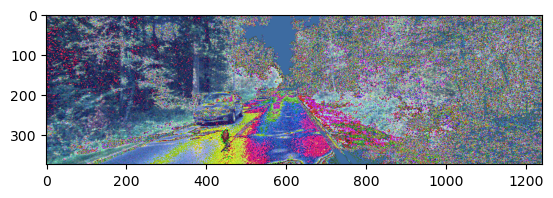

torch.Size([3, 375, 1242])
['type', 'truncated', 'occluded', 'alpha', 'bbox', 'dimensions', 'location', 'rotation_y']

------objects------
[{'type': 'Car', 'truncated': 0.0, 'occluded': 0, 'alpha': 1.82, 'bbox': [360.9, 189.01, 501.88, 280.68], 'dimensions': [1.52, 1.73, 4.28], 'location': [-3.46, 1.88, 14.64], 'rotation_y': 1.59}, {'type': 'Car', 'truncated': 0.0, 'occluded': 0, 'alpha': 1.69, 'bbox': [523.92, 182.29, 564.4, 211.63], 'dimensions': [1.44, 1.7, 3.65], 'location': [-3.44, 1.95, 37.98], 'rotation_y': 1.6}]


In [5]:
# 데이터셋 확인
idx = random.randint(0, len(train_dataset)-1)   # 한 장의 샘플 데이터를 무작위로 추출합니다.
sample = train_dataset[idx]

print("Image index:", idx)

print('------Example------')
image = sample[0]
img = TF.to_pil_image(image)
plt.imshow(img)
plt.show()
print(np.shape(image))
print(list(sample[1][0].keys()))

print('\n------objects------')
objects = sample[1]
print(objects)

In [6]:
# 클래스 정의
CLASS_COLORS = {
    'Car':             (255,   0,   0),   # 빨강
    'Van':             (255, 128,   0),   # 주황
    'Truck':           (255, 255,   0),   # 노랑
    'Pedestrian':      (  0, 255,   0),   # 초록
    'Person_sitting':  (  0, 255, 128),   # 연두
    'Cyclist':         (  0, 128, 255),   # 하늘색
    'Tram':            (128,   0, 255),   # 보라
    'Misc':            (255,   0, 255),   # 마젠타
    'DontCare':        (189,   195, 199),   # 회색
}

CLASS_NAMES = ['Car', 'Van', 'Truck', 'Pedestrian',
               'Person_sitting', 'Cyclist', 'Tram', 'Misc', 'DontCare']

# 사람 관련 클래스
PERSON_CLASSES = {'Pedestrian', 'Person_sitting', 'Cyclist'}

print("클래스 정의 완료:", CLASS_NAMES)

클래스 정의 완료: ['Car', 'Van', 'Truck', 'Pedestrian', 'Person_sitting', 'Cyclist', 'Tram', 'Misc', 'DontCare']


In [7]:
# 숫자 ID를 클래스 이름으로 변환하는 딕셔너리 정의
# 학습 시 사용한 클래스 순서와 동일해야 함!
ID_TO_CLASS = {
    0: 'Car', 
    1: 'Van', 
    2: 'Truck', 
    3: 'Pedestrian', 
    4: 'Person_sitting', 
    5: 'Cyclist', 
    6: 'Tram', 
    7: 'Misc'
}

## 3. 모델 구성 (RetinaNet)

In [8]:
# ── AnchorBox ──────────────────────────────────────────────────────
class AnchorBox:
    def __init__(
        self,
        aspect_ratios=[0.5, 1.0, 2.0],
        scales=[2**0, 2**(1/3), 2**(2/3)],
        areas=[32.0**2, 64.0**2, 128.0**2, 256.0**2, 512.0**2]
    ):
        self.aspect_ratios = aspect_ratios
        self.scales = scales
        self.areas = areas
        self._num_anchors = len(aspect_ratios) * len(scales)
        self._strides = [2**i for i in range(3, 8)]
        self._anchor_dims = self._compute_dims()

    def _compute_dims(self):
        anchor_dims_all = []
        for area in self.areas:
            anchor_dims = []
            for ratio in self.aspect_ratios:
                anchor_height = torch.sqrt(torch.tensor(area / ratio))
                anchor_width  = area / anchor_height
                dims = torch.stack([anchor_width, anchor_height], dim=-1)
                dims = dims.unsqueeze(0).unsqueeze(0)
                for scale in self.scales:
                    anchor_dims.append(scale * dims)
            anchor_dims_all.append(torch.stack(anchor_dims, dim=-2))
        return anchor_dims_all

    def _get_anchors(self, feature_height, feature_width, level):
        rx = torch.arange(feature_width,  dtype=torch.float32) + 0.5
        ry = torch.arange(feature_height, dtype=torch.float32) + 0.5
        centers = torch.stack(torch.meshgrid(rx, ry, indexing='xy'), dim=-1)
        centers = centers * self._strides[level - 3]
        centers = centers.unsqueeze(-2)
        centers = centers.repeat(1, 1, self._num_anchors, 1)
        dims = self._anchor_dims[level - 3].repeat(feature_height, feature_width, 1, 1)
        anchors = torch.cat([centers, dims], dim=-1)
        return anchors.view(feature_height * feature_width * self._num_anchors, 4)

    def get_anchors(self, image_height, image_width):
        anchors = [
            self._get_anchors(
                torch.ceil(torch.tensor(image_height / (2**i))).int().item(),
                torch.ceil(torch.tensor(image_width  / (2**i))).int().item(),
                i
            )
            for i in range(3, 8)
        ]
        return torch.cat(anchors, dim=0)


# ── 좌표 변환 헬퍼 ────────────────────────────────────────────────
def convert_to_corners(boxes):
    return torch.cat(
        [boxes[..., :2] - boxes[..., 2:] / 2.0,
         boxes[..., :2] + boxes[..., 2:] / 2.0],
        dim=-1
    )

def convert_to_xywh(boxes):
    return torch.cat(
        [(boxes[..., :2] + boxes[..., 2:]) / 2.0,
         boxes[..., 2:] - boxes[..., :2]],
        dim=-1
    )

print("AnchorBox / 좌표 변환 함수 정의 완료")

AnchorBox / 좌표 변환 함수 정의 완료


In [9]:
# ── ResNet50 Backbone ──────────────────────────────────────────────
def get_resnet50_backbone(pretrained=True):
    resnet = models.resnet50(weights='IMAGENET1K_V1' if pretrained else None)

    class ResNet50Backbone(nn.Module):
        def __init__(self, resnet_model):
            super().__init__()
            self.conv1   = resnet_model.conv1
            self.bn1     = resnet_model.bn1
            self.relu    = resnet_model.relu
            self.maxpool = resnet_model.maxpool
            self.layer1  = resnet_model.layer1
            self.layer2  = resnet_model.layer2
            self.layer3  = resnet_model.layer3
            self.layer4  = resnet_model.layer4

        def forward(self, x):
            x  = self.conv1(x)
            x  = self.bn1(x)
            x  = self.relu(x)
            x  = self.maxpool(x)
            x  = self.layer1(x)
            c3 = self.layer2(x)
            c4 = self.layer3(c3)
            c5 = self.layer4(c4)
            return c3, c4, c5

    return ResNet50Backbone(resnet)


# ── Feature Pyramid Network ────────────────────────────────────────
class FeaturePyramid(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone     = backbone
        self.conv_c3_1x1  = nn.Conv2d(512,  256, 1)
        self.conv_c4_1x1  = nn.Conv2d(1024, 256, 1)
        self.conv_c5_1x1  = nn.Conv2d(2048, 256, 1)
        self.conv_c3_3x3  = nn.Conv2d(256,  256, 3, padding=1)
        self.conv_c4_3x3  = nn.Conv2d(256,  256, 3, padding=1)
        self.conv_c5_3x3  = nn.Conv2d(256,  256, 3, padding=1)
        self.conv_c6_3x3  = nn.Conv2d(2048, 256, 3, stride=2, padding=1)
        self.conv_c7_3x3  = nn.Conv2d(256,  256, 3, stride=2, padding=1)

    def forward(self, images):
        c3, c4, c5 = self.backbone(images)
        p5 = self.conv_c5_1x1(c5)
        p4 = self.conv_c4_1x1(c4) + F.interpolate(p5, size=c4.shape[-2:], mode='nearest')
        p3 = self.conv_c3_1x1(c3) + F.interpolate(p4, size=c3.shape[-2:], mode='nearest')
        p3 = self.conv_c3_3x3(p3)
        p4 = self.conv_c4_3x3(p4)
        p5 = self.conv_c5_3x3(p5)
        p6 = self.conv_c6_3x3(c5)
        p7 = self.conv_c7_3x3(F.relu(p6))
        return p3, p4, p5, p6, p7


# ── Detection Head 빌더 ───────────────────────────────────────────
def build_head(output_filters, bias_init, num_convs=4):
    layers = []
    for _ in range(num_convs):
        layers += [nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(inplace=True)]
    layers.append(nn.Conv2d(256, output_filters, 3, padding=1))
    for layer in layers:
        if isinstance(layer, nn.Conv2d):
            nn.init.normal_(layer.weight, 0.0, 0.01)
            if layer.bias is not None:
                nn.init.constant_(layer.bias, 0.0)
    nn.init.constant_(layers[-1].bias, bias_init)
    return nn.Sequential(*layers)


# ── RetinaNet ─────────────────────────────────────────────────────
class RetinaNet(nn.Module):
    def __init__(self, num_classes, backbone=None):
        super().__init__()
        if backbone is None:
            backbone = get_resnet50_backbone(pretrained=True)
        self.fpn = FeaturePyramid(backbone)
        self.num_classes = num_classes
        prior_prob  = 0.01
        bias_value  = -np.log((1 - prior_prob) / prior_prob)
        self.cls_head = build_head(9 * num_classes, bias_value)
        self.box_head = build_head(9 * 4, 0.0)

    def forward(self, images):
        features = self.fpn(images)
        N = images.size(0)
        cls_outputs, box_outputs = [], []
        for feature in features:
            box_out = self.box_head(feature).permute(0,2,3,1).contiguous().view(N,-1,4)
            cls_out = self.cls_head(feature).permute(0,2,3,1).contiguous().view(N,-1,self.num_classes)
            box_outputs.append(box_out)
            cls_outputs.append(cls_out)
        return torch.cat([torch.cat(box_outputs,1), torch.cat(cls_outputs,1)], dim=-1)

print("RetinaNet 모델 클래스 정의 완료")

RetinaNet 모델 클래스 정의 완료


In [10]:
# ── DecodePredictions ─────────────────────────────────────────────
class DecodePredictions(nn.Module):
    """
    RetinaNet 예측을 실제 bounding boxes로 디코딩
    """
    def __init__(
        self,
        num_classes=8,
        confidence_threshold=0.3,
        nms_iou_threshold=0.5,
        max_detections=100,
        box_variance=[0.1, 0.1, 0.2, 0.2]
    ):
        super().__init__()
        self.num_classes          = num_classes
        self.confidence_threshold = confidence_threshold
        self.nms_iou_threshold    = nms_iou_threshold
        self.max_detections       = max_detections
        self._anchor_box          = AnchorBox()
        self._box_variance        = torch.tensor(box_variance, dtype=torch.float32)

    def _decode_box_predictions(self, anchor_boxes, box_predictions):
        boxes = box_predictions * self._box_variance.to(box_predictions.device)
        boxes = torch.cat(
            [
                boxes[:,:,:2] * anchor_boxes[:,:,2:] + anchor_boxes[:,:,:2],
                torch.exp(boxes[:,:,2:]) * anchor_boxes[:,:,2:]
            ],
            dim=-1
        )
        return convert_to_corners(boxes)

    def forward(self, images, predictions):
        image_shape  = images.shape
        anchor_boxes = self._anchor_box.get_anchors(image_shape[2], image_shape[3]).to(predictions.device)
        box_preds    = predictions[:,:,:4]
        cls_preds    = torch.sigmoid(predictions[:,:,4:])
        boxes        = self._decode_box_predictions(anchor_boxes[None,...], box_preds)

        batch_results = []
        for i in range(boxes.shape[0]):
            sel_boxes, sel_scores, sel_classes = [], [], []
            for class_id in range(self.num_classes):
                class_scores = cls_preds[i, :, class_id]
                mask = class_scores > self.confidence_threshold
                if mask.sum() == 0:
                    continue
                cb = boxes[i, mask]
                cs = class_scores[mask]
                keep = nms(cb, cs, self.nms_iou_threshold)
                sel_boxes.append(cb[keep])
                sel_scores.append(cs[keep])
                sel_classes.append(torch.full((len(keep),), class_id, dtype=torch.int64))

            if sel_boxes:
                all_boxes   = torch.cat(sel_boxes)
                all_scores  = torch.cat(sel_scores)
                all_classes = torch.cat(sel_classes)
                if len(all_scores) > self.max_detections:
                    topk = torch.topk(all_scores, self.max_detections).indices
                    all_boxes, all_scores, all_classes = all_boxes[topk], all_scores[topk], all_classes[topk]
            else:
                all_boxes   = torch.zeros((0, 4))
                all_scores  = torch.zeros((0,))
                all_classes = torch.zeros((0,), dtype=torch.int64)

            batch_results.append((all_boxes, all_scores, all_classes))
        return batch_results

## 4. Baseline 평가

예제 코드를 baseline으로 삼아 학습된 모델을 불러와 자율주행 보조 성능을 평가하고 개선 방향을 설정한다.

##### 정지 조건
1. 사람 클래스 탐지: `Pedestrian`, `Person_sitting`, `Cyclist` 중 1명 이상
2. 근거리 차량 탐지: 바운딩 박스 `width` 또는 `height` ≥ `size_limit`(기본 300px)
3. 탐지 실패: 이미지를 읽을 수 없거나 모델 오류 발생 시 안전을 위해 Stop

> 위 조건 중 하나라도 충족되면 **"Stop"**, 모두 해당 없으면 **"Go"** 반환

In [11]:
# ── 모델 로드 함수 ────────────────────────────────────────────────
def load_model(checkpoint_path, num_classes=8, device=None):
    """학습된 RetinaNet 모델 로드"""
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    else:
        device = torch.device(device)

    backbone = get_resnet50_backbone(pretrained=False)
    model    = RetinaNet(num_classes=num_classes, backbone=backbone)

    try:
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"✅ 모델 로드 완료: {checkpoint_path}")
        print(f"   Epoch: {checkpoint.get('epoch', 'N/A')}, "
              f"Loss: {checkpoint.get('loss', float('nan')):.4f}")
    except FileNotFoundError:
        print(f"⚠️  체크포인트를 찾을 수 없습니다: {checkpoint_path}")
        print("   → pretrained backbone 가중치만으로 진행합니다.")

    model = model.to(device)
    model.eval()

    decoder = DecodePredictions(
        num_classes=num_classes,
        confidence_threshold=0.3,
        nms_iou_threshold=0.5,
        max_detections=100
    )
    return model, decoder, device

print("DecodePredictions / load_model 정의 완료")

DecodePredictions / load_model 정의 완료


In [12]:
# 모델 준비
try:
    # model 변수가 이미 존재하고 학습 직후라면 그대로 사용 가능하지만,
    # 분석의 객관성을 위해 저장된 '최적 가중치'를 불러오는 것을 권장합니다.
    if 'model' not in locals():
        print("💡 메모리에 모델이 없습니다. 저장된 체크포인트를 로드합니다.")
        model, decoder, device = load_model(CHECKPOINT_PATH, num_classes=8)
    else:
        print("✅ 기존 모델 변수를 감지했습니다. 최신 가중치로 업데이트하려면 load_model을 실행하세요.")
        # 선택 사항: 확실한 성능 확인을 위해 그냥 한번 더 로드해도 무방함
        # model, decoder, device = load_model(CHECKPOINT_PATH, num_classes=9)
except NameError:
    model, decoder, device = load_model(CHECKPOINT_PATH, num_classes=8)

💡 메모리에 모델이 없습니다. 저장된 체크포인트를 로드합니다.
✅ 모델 로드 완료: /home/jovyan/work/object_detection/checkpoints/best.pth
   Epoch: 4, Loss: 0.3247


In [13]:
# ── 전역 모델 캐시 (반복 로드 방지) ──────────────────────────────
_cached_model   = None
_cached_decoder = None
_cached_device  = None

def _get_model(checkpoint_path=CHECKPOINT_PATH):
    """모델을 처음 한 번만 로드하고 캐싱"""
    global _cached_model, _cached_decoder, _cached_device
    if _cached_model is None:
        _cached_model, _cached_decoder, _cached_device = load_model(checkpoint_path)
    return _cached_model, _cached_decoder, _cached_device


def self_drive_assist(img_path: str, size_limit: int = 300) -> str:
    """
    자율주행 보조 판단 함수

    Args:
        img_path   : 판단할 이미지 경로
        size_limit : 차량 바운딩 박스 크기 임계값 (px, default=300)

    Returns:
        'Stop' or 'Go'

    정지 조건:
        1. 사람(Pedestrian / Person_sitting / Cyclist)이 1명 이상 탐지
        2. 차량 bbox의 width 또는 height >= size_limit
        3. 예외 상황(이미지 로드 실패, 모델 오류) → 안전 우선으로 Stop
    """
    # ── 예외 처리: 파일 존재 확인 ─────────────────────────────────
    if not os.path.exists(img_path):
        print(f"[WARN] 이미지 파일 없음: {img_path} → Stop (안전 우선)")
        return "Stop"

    try:
        # ── 이미지 로드 ───────────────────────────────────────────
        image = Image.open(img_path).convert('RGB')
        original_size = image.size           # (width, height)
        img_size      = (384, 1280)          # 모델 입력 크기 (H, W)

        scale_w = img_size[1] / original_size[0]
        scale_h = img_size[0] / original_size[1]

        # ── 전처리 ────────────────────────────────────────────────
        transform = transforms.Compose([
            transforms.Resize(img_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std =[0.229, 0.224, 0.225])
        ])
        model, decoder, device = _get_model()
        image_tensor = transform(image).unsqueeze(0).to(device)

        # ── 추론 ──────────────────────────────────────────────────
        with torch.no_grad():
            predictions = model(image_tensor)
            decoded     = decoder(image_tensor, predictions)

        boxes, scores, classes = decoded[0]

        # 탐지 결과가 없는 경우
        if len(boxes) == 0:
            return "Go"

        boxes   = boxes.cpu().numpy()
        classes = classes.cpu().numpy()

        # ── 판단 로직 ─────────────────────────────────────────────
        for box, cls_id in zip(boxes, classes):
            class_name = CLASS_NAMES[cls_id]

            # 조건 1: 사람 클래스 탐지
            if class_name in PERSON_CLASSES:
                return "Stop"

            # 조건 2: 차량 bbox 크기 >= size_limit (원본 좌표 기준)
            x1, y1, x2, y2 = box
            orig_w = (x2 - x1) / scale_w
            orig_h = (y2 - y1) / scale_h
            if orig_w >= size_limit or orig_h >= size_limit:
                return "Stop"

        return "Go"

    except Exception as e:
        # 조건 3: 예외 발생 시 안전 우선으로 Stop
        print(f"[ERROR] 처리 중 오류 발생: {e} → Stop (안전 우선)")
        return "Stop"


print("self_drive_assist 함수 정의 완료")

self_drive_assist 함수 정의 완료


In [14]:
# 단일 이미지 테스트
temp_img_path = os.path.join(os.getenv('HOME'), 'work/object_detection/data/stop_1.png') # 모델 정상 작동 여부 판단
result = self_drive_assist(temp_img_path)
print(f"\n판단 결과: [{result}]")

✅ 모델 로드 완료: /home/jovyan/work/object_detection/checkpoints/best.pth
   Epoch: 4, Loss: 0.3247

판단 결과: [Go]


체크포인트 모델이 정상 작동하는 것을 확인했으므로 10장의 테스트 이미지 (stop 5장 / go 5장)에 대해 정답과 비교하여 100점 만점을 기준으로 자율 주행 시스템을 평가한다.

In [15]:
def test_system(func):
    """자율주행 보조 시스템 평가 함수 (10장 × 10점 = 100점)"""
    work_dir = os.path.join(os.getenv('HOME'), 'work/object_detection/data')
    score = 0
    test_set = [
        ("stop_1.png", "Stop"),
        ("stop_2.png", "Stop"),
        ("stop_3.png", "Stop"),
        ("stop_4.png", "Stop"),
        ("stop_5.png", "Stop"),
        ("go_1.png",   "Go"),
        ("go_2.png",   "Go"),
        ("go_3.png",   "Go"),
        ("go_4.png",   "Go"),
        ("go_5.png",   "Go"),
    ]

    print("=" * 55)
    print(f"{'파일':<18} {'정답':<8} {'예측':<8} {'결과'}")
    print("=" * 55)

    results = []
    for image_file, answer in test_set:
        image_path = os.path.join(work_dir, image_file)
        pred       = func(image_path)
        correct    = (pred == answer)
        if correct:
            score += 10
        mark = "✅" if correct else "❌"
        print(f"{image_file:<18} {answer:<8} {pred:<8} {mark}")
        results.append((image_file, answer, pred, correct))

    print("=" * 55)
    print(f"\n🏆 최종 점수: {score}점 / 100점")
    return score, results


score, results = test_system(self_drive_assist)

파일                 정답       예측       결과
stop_1.png         Stop     Go       ❌
stop_2.png         Stop     Go       ❌
stop_3.png         Stop     Go       ❌
stop_4.png         Stop     Stop     ✅
stop_5.png         Stop     Go       ❌
go_1.png           Go       Go       ✅
go_2.png           Go       Go       ✅
go_3.png           Go       Go       ✅
go_4.png           Go       Go       ✅
go_5.png           Go       Go       ✅

🏆 최종 점수: 60점 / 100점


평가 결과를 시각화하여 모델의 취약점과 강점을 파악한다. 시각화 시 바운딩 박스와 클래스명·신뢰도를 이미지 위에 표시한다.

In [16]:
def visualize_detection(
    image_path: str,
    checkpoint_path: str = CHECKPOINT_PATH,
    output_path: str     = None,
    img_size: Tuple      = (384, 1280),
    show_scores: bool    = True,
    min_score: float     = 0.3,
) -> Image.Image:
    """
    이미지에 탐지 결과(바운딩 박스 + 라벨)를 시각화

    Args:
        image_path      : 원본 이미지 경로
        checkpoint_path : 모델 체크포인트 경로
        output_path     : 저장 경로 (None 이면 저장 안 함)
        img_size        : 모델 입력 크기 (H, W)
        show_scores     : 신뢰도 점수 표시 여부
        min_score       : 표시할 최소 신뢰도

    Returns:
        바운딩 박스가 그려진 PIL Image
    """
    model, decoder, device = _get_model(checkpoint_path)

    image         = Image.open(image_path).convert('RGB')
    original_size = image.size   # (W, H)
    scale_w = img_size[1] / original_size[0]
    scale_h = img_size[0] / original_size[1]

    transform = transforms.Compose([
        transforms.Resize(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std =[0.229, 0.224, 0.225])
    ])
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        predictions = model(image_tensor)
        decoded     = decoder(image_tensor, predictions)

    boxes, scores, classes = decoded[0]
    boxes   = boxes.cpu().numpy()
    scores  = scores.cpu().numpy()
    classes = classes.cpu().numpy()

    # ── 바운딩 박스 그리기 ────────────────────────────────────────
    draw_image = image.copy()
    draw       = ImageDraw.Draw(draw_image)

    try:
        font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 16)
    except:
        font = ImageFont.load_default()

    detection_count = 0
    class_counts    = {}

    for box, score, cls_id in zip(boxes, scores, classes):
        if score < min_score:
            continue
        detection_count += 1

        # 원본 좌표로 역변환
        x1 = box[0] / scale_w
        y1 = box[1] / scale_h
        x2 = box[2] / scale_w
        y2 = box[3] / scale_h

        class_name = CLASS_NAMES[cls_id]
        color      = CLASS_COLORS.get(class_name, (255, 255, 255))
        class_counts[class_name] = class_counts.get(class_name, 0) + 1

        # 바운딩 박스
        draw.rectangle([x1, y1, x2, y2], outline=color, width=2)

        # 라벨 텍스트 (result_09.png 스타일: "Car 0.87")
        label     = f"{class_name}{score:.2f}" if show_scores else class_name
        text_bbox = draw.textbbox((x1, y1), label, font=font)
        draw.text((x1, y1), label, fill=color, font=font)

    # ── 콘솔 요약 출력 ────────────────────────────────────────────
    print(f"\n탐지 완료!")
    print(f"   총 {detection_count}개 객체 탐지")
    if class_counts:
        print("   클래스별 개수:")
        for cls_name, cnt in sorted(class_counts.items()):
            print(f"     - {cls_name}: {cnt}")

    if output_path:
        os.makedirs(os.path.dirname(output_path) if os.path.dirname(output_path) else '.', exist_ok=True)
        draw_image.save(output_path)
        print(f"결과 저장: {output_path}")

    return draw_image

print("visualize_detection 함수 정의 완료")

visualize_detection 함수 정의 완료



탐지 완료!
   총 0개 객체 탐지
결과 저장: result_assist_v2/stop_1.png

탐지 완료!
   총 0개 객체 탐지
결과 저장: result_assist_v2/stop_2.png

탐지 완료!
   총 4개 객체 탐지
   클래스별 개수:
     - Car: 3
     - Tram: 1
결과 저장: result_assist_v2/stop_3.png

탐지 완료!
   총 15개 객체 탐지
   클래스별 개수:
     - Car: 11
     - Misc: 1
     - Van: 3
결과 저장: result_assist_v2/stop_4.png

탐지 완료!
   총 6개 객체 탐지
   클래스별 개수:
     - Car: 5
     - Van: 1
결과 저장: result_assist_v2/stop_5.png

탐지 완료!
   총 8개 객체 탐지
   클래스별 개수:
     - Car: 3
     - Tram: 2
     - Truck: 3
결과 저장: result_assist_v2/go_1.png

탐지 완료!
   총 2개 객체 탐지
   클래스별 개수:
     - Car: 2
결과 저장: result_assist_v2/go_2.png

탐지 완료!
   총 2개 객체 탐지
   클래스별 개수:
     - Car: 2
결과 저장: result_assist_v2/go_3.png

탐지 완료!
   총 1개 객체 탐지
   클래스별 개수:
     - Car: 1
결과 저장: result_assist_v2/go_4.png

탐지 완료!
   총 1개 객체 탐지
   클래스별 개수:
     - Car: 1
결과 저장: result_assist_v2/go_5.png


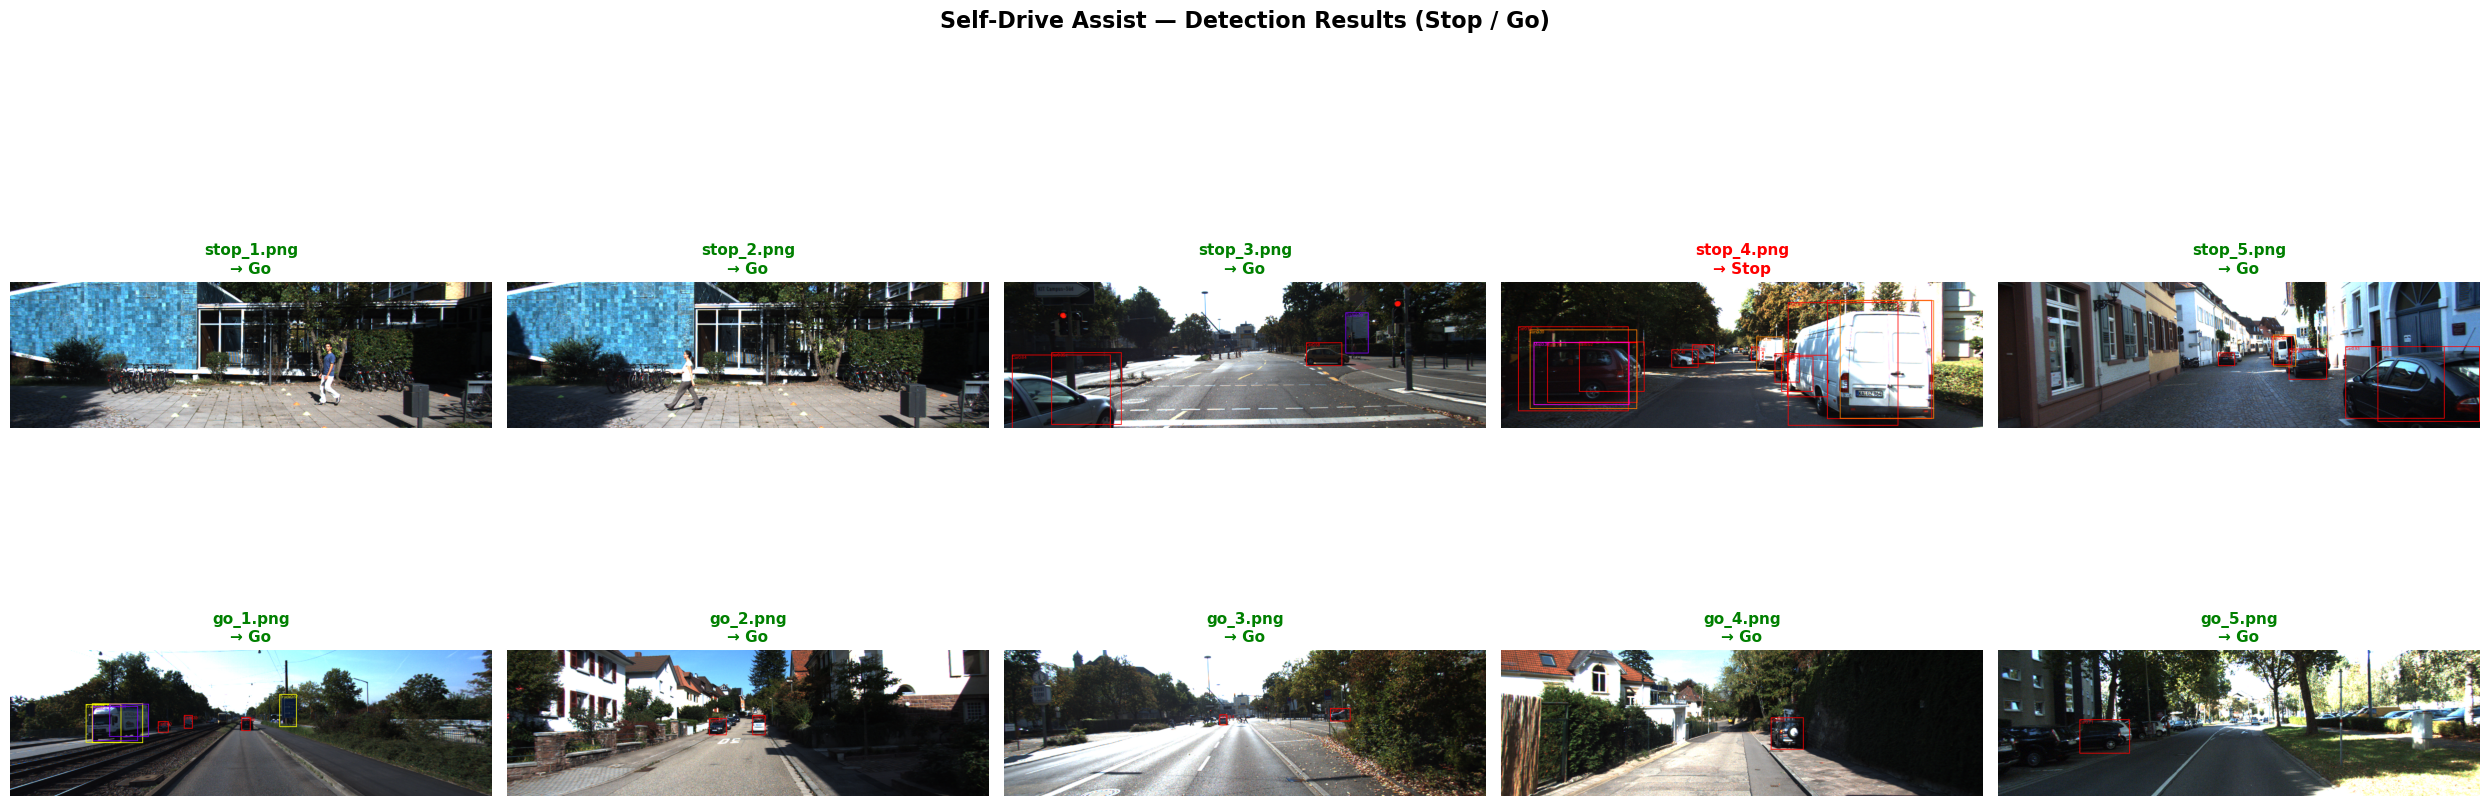


시각화 완료! → result_assist_v2/all_results_v2.png


In [17]:
# 테스트 이미지 전체 시각화
test_images = [
    "stop_1.png", "stop_2.png", "stop_3.png", "stop_4.png", "stop_5.png",
    "go_1.png",   "go_2.png",   "go_3.png",   "go_4.png",   "go_5.png",
]

fig, axes = plt.subplots(2, 5, figsize=(25, 10))
axes = axes.flatten()

for idx, fname in enumerate(test_images):
    img_path    = os.path.join(DATA_DIR, fname)
    output_path = f'result_assist_v2/{fname}'
    pred        = self_drive_assist(img_path)

    result_img = visualize_detection(
        img_path,
        output_path=output_path,
        show_scores=True
    )

    # 판단 결과 색상: Stop=빨강, Go=초록
    border_color = 'red' if pred == 'Stop' else 'limegreen'
    title_color  = 'red' if pred == 'Stop' else 'green'

    axes[idx].imshow(result_img)
    axes[idx].set_title(f"{fname}\n→ {pred}",
                        color=title_color, fontsize=11, fontweight='bold')
    axes[idx].axis('off')
    for spine in axes[idx].spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(4)

plt.suptitle('Self-Drive Assist — Detection Results (Stop / Go)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('result_assist_v2/all_results_v2.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n시각화 완료! → result_assist_v2/all_results_v2.png")

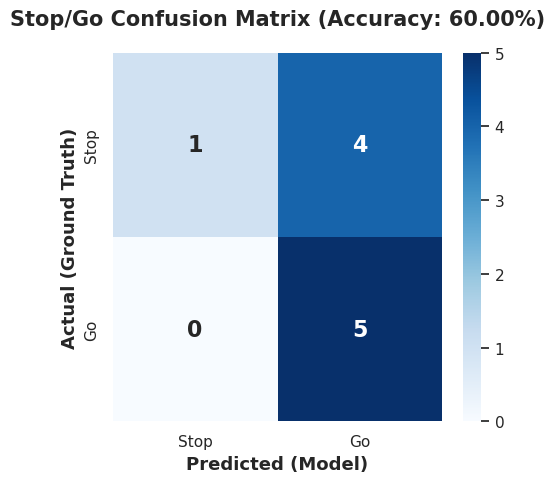

혼동 행렬 저장 완료: result_assist_v2/confusion_matrix.png

[분석 결과]
- 정지 판단 정확도: 1/5
- 주행 판단 정확도: 5/5
⚠️ 경고: 정지해야 할 상황에서 주행(Go)한 경우가 4건 발생했습니다.


In [18]:
# 결과 요약 시각화 (Confusion Matrix 버전)
if 'results' in dir() and results:
    # 1. 실제값(y_true)과 예측값(y_pred) 리스트 생성
    # results 구조: (이미지명, 정답_ans, 예측_pred, 일치여부_ok)
    y_true = [ans for _, ans, pred, ok in results]
    y_pred = [pred for _, ans, pred, ok in results]
    labels = ['Stop', 'Go']

    # 2. Confusion Matrix 계산
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    # 3. 시각화 설정
    plt.figure(figsize=(5, 5))
    sns.set(style='white')
    
    # 히트맵 그리기
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels,
                annot_kws={"size": 16, "weight": "bold"})
    
    # 축 설정 및 타이틀
    plt.xlabel('Predicted (Model)', fontsize=13, fontweight='bold')
    plt.ylabel('Actual (Ground Truth)', fontsize=13, fontweight='bold')
    
    accuracy = np.sum(np.diag(cm)) / np.sum(cm)
    plt.title(f'Stop/Go Confusion Matrix (Accuracy: {accuracy:.2%})', 
              fontsize=15, pad=20, fontweight='bold')

    # 저장 및 출력
    plt.tight_layout()
    os.makedirs('result_assist_v2', exist_ok=True)
    plt.savefig('result_assist_v2/confusion_matrix.png', dpi=120, bbox_inches='tight')
    plt.show()
    
    print(f"혼동 행렬 저장 완료: result_assist_v2/confusion_matrix.png")
    
    # 정량적 수치 해석 출력
    tn, fp, fn, tp = cm.ravel() # labels=['Stop', 'Go'] 순서 기준
    print(f"\n[분석 결과]")
    print(f"- 정지 판단 정확도: {tn}/{tn+fp}")
    print(f"- 주행 판단 정확도: {tp}/{fn+tp}")
    if fp > 0:
        print(f"⚠️ 경고: 정지해야 할 상황에서 주행(Go)한 경우가 {fp}건 발생했습니다.")

혼동 행렬에서 Actual: Stop / Predicted: Go 영역에 숫자가 찍혀 있다면, 이는 모델이 보행자를 놓쳐서 그냥 주행하겠다고 판단한 위험한 상황이다.

##### **Baseline 평가 결과 해석**

**1. 보행자 미검출 문제:**

   테스트 이미지에서, 보행자는 아예 검출이 되지 않았다 (바운딩 박스 없음). 이는 보행자의 존재 자체를 무시하고 지나친 것으로 보행자 클래스 데이터의 부족을 시사한다. 즉 KITTI 데이터셋에 심각한 데이터 불균형이 존재함을 의미한다. 아래 EDA 파트에서 이를 확인한다.

**2. 부분 노출 객체 인식 한계:**

   이미지 가장자리에 걸쳐 차체의 일부만 보이는 Truncated 자동차를 모델이 배경이나 노이즈로 오판하여 주행(Go) 결정을 내리는 위험이 있다.


**3. 중복 검출 문제:**  

NMS 알고리즘에서 가장 점수가 높은 박스 하나만 남기고 나머지는 제거되어야 하는데, 이 과정이 누락되었거나 IoU Threshold가 너무 높게 설정되어 비슷한 박스들이 모두 살아남았다. 만약 자동차 클래스 하나에 박스가 10개씩 생기면 모델학습이 자동차 클래스로만 편중되어 다른 클래스를 잘 판별하지 못한다.

## 5. EDA

EDA 단계에서는 Baseline 평가 단계에서 제기된 클래스 불균형 문제 등을 확인하고 해결 방안을 고안한다.

In [19]:
# 전체 레이블 파싱
def parse_all_labels(label_dir):
    """
    모든 레이블 파일을 파싱하여 객체 속성 딕셔너리 리스트 반환
    기준 필드: type, truncated, occluded, bbox, 이미지 크기
    """
    records = []
    label_files = sorted([f for f in os.listdir(label_dir) if f.endswith('.txt')])

    for fname in label_files:
        lpath = os.path.join(label_dir, fname)
        ipath = os.path.join(IMG_DIR, fname.replace('.txt', '.png'))

        # 이미지 크기 (있을 때만)
        img_w, img_h = None, None
        if os.path.exists(ipath):
            img = Image.open(ipath)
            img_w, img_h = img.size   # (W, H)

        with open(lpath) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 15:
                    continue
                cls_name  = parts[0]
                truncated = float(parts[1])
                occluded  = int(parts[2])
                x1, y1, x2, y2 = map(float, parts[4:8])
                w_box = x2 - x1
                h_box = y2 - y1

                # KITTI 공식 난이도 판정
                if   truncated <= 0.15 and occluded == 0 and h_box >= 40:
                    difficulty = 'Easy'
                elif truncated <= 0.30 and occluded <= 1 and h_box >= 25:
                    difficulty = 'Moderate'
                elif truncated <= 0.50 and occluded <= 2 and h_box >= 25:
                    difficulty = 'Hard'
                else:
                    difficulty = 'Very Hard'

                records.append({
                    'file':       fname,
                    'class':      cls_name,
                    'truncated':  truncated,
                    'occluded':   occluded,
                    'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2,
                    'w_box':      w_box,
                    'h_box':      h_box,
                    'cx':         (x1 + x2) / 2,
                    'cy':         (y1 + y2) / 2,
                    'area_px':    w_box * h_box,
                    'area_ratio': (w_box * h_box / (img_w * img_h)) if img_w else None,
                    'img_w':      img_w,
                    'img_h':      img_h,
                    'difficulty': difficulty,
                })

    print(f'총 객체 수 : {len(records):,}개')
    print(f'총 학습 이미지 수: {len(label_files):,}장')
    return records

records = parse_all_labels(LABEL_DIR)

총 객체 수 : 51,865개
총 학습 이미지 수: 7,481장


### 클래스 분포

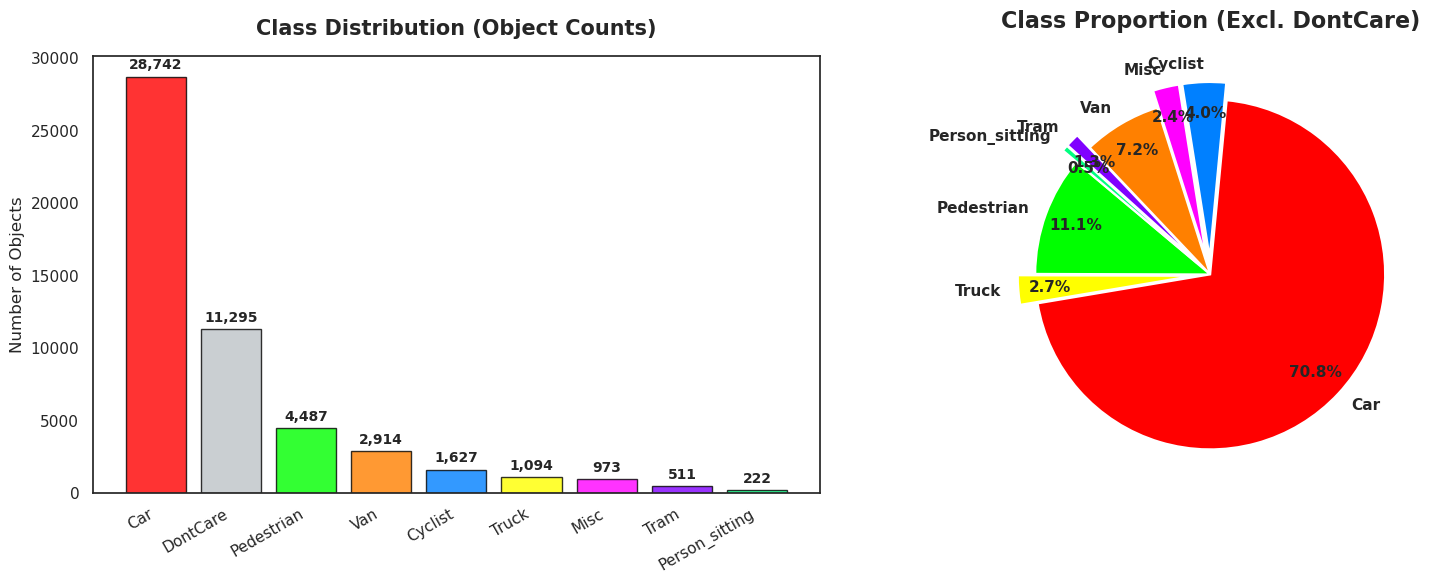

클래스 분포 시각화 완료: eda_class_balance.png


In [20]:
# 클래스 분포 (Class Balance) 확인
def plot_class_balance(records):
    """
    KITTI 데이터셋의 클래스 분포를 시각화하는 함수
    """
    # 1. 클래스별 개수 집계 및 정렬
    cls_counter = Counter(r['class'] for r in records)
    classes = sorted(cls_counter, key=cls_counter.get, reverse=True)
    counts  = [cls_counter[c] for c in classes]

    # 2. 색상 값 정규화 (0~255 -> 0~1) 및 에러 방지
    # CLASS_COLORS에서 색상을 가져오되, 없는 클래스는 회색(128,128,128) 처리
    colors = [tuple(v/255.0 for v in CLASS_COLORS.get(cls, (128, 128, 128))) for cls in classes]

    # 3. 그래프 초기화 (한글 깨짐 방지를 위해 영문 라벨 사용 권장)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # --- (1) 막대 그래프 영역 ---
    axes[0].bar(classes, counts, color=colors, edgecolor='black', alpha=0.8)
    axes[0].set_title('Class Distribution (Object Counts)', fontsize=15, fontweight='bold', pad=15)
    axes[0].set_ylabel('Number of Objects', fontsize=12)
    
    # UserWarning 해결: xticks를 먼저 설정
    axes[0].set_xticks(range(len(classes)))
    axes[0].set_xticklabels(classes, rotation=30, ha='right', fontsize=11)
    
    # 막대 위에 숫자 표시
    for i, cnt in enumerate(counts):
        axes[0].text(i, cnt + (max(counts) * 0.01), f'{cnt:,}', 
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

    # --- (2) 파이 차트 영역 (DontCare 제외) ---
    cls_no_dc = {c: v for c, v in cls_counter.items() if c != 'DontCare'}
    pie_labels = list(cls_no_dc.keys())
    pie_values = list(cls_no_dc.values())
    pie_colors = [tuple(v/255.0 for v in CLASS_COLORS.get(c, (128, 128, 128))) for c in pie_labels]

    # 데이터 불균형으로 인한 글자 겹침 방지 설정
    # 비율이 5% 미만인 작은 클래스들을 살짝 밖으로 분리(explode)
    total_pie = sum(pie_values)
    explode = [0.1 if (v / total_pie) < 0.05 else 0 for v in pie_values]

    axes[1].pie(
        pie_values, 
        labels=pie_labels, 
        colors=pie_colors,
        autopct='%1.1f%%', 
        startangle=140,
        explode=explode,          # 작은 조각 분리
        pctdistance=0.82,         # 퍼센트 텍스트 위치 (중심에서 0.82 거리)
        labeldistance=1.1,        # 클래스 라벨 위치
        textprops={'fontsize': 11, 'fontweight': 'bold'},
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
    )
    axes[1].set_title('Class Proportion (Excl. DontCare)', fontsize=16, fontweight='bold', pad=20)

    # 4. 레이아웃 조정 및 저장
    plt.tight_layout()
    save_path = 'eda_class_balance.png'
    plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()
    
    print(f'클래스 분포 시각화 완료: {save_path}')

# 함수 실행
plot_class_balance(records)

##### **클래스 분포 그래프 해석**

**1. 극심한 클래스 불균형**

   자동차 (Car) 클래스가 다른 모든 클래스를 합친 것보다도 많다. 이 경우 모델이 자동차만 잘 맞추는 쪽으로 편향된 학습을 할 가능성이 높다. 특히 보행자 클래스의 비중이 낮은데, 자율주행에서 보행자 미검출은 치명적이다. 이 때문에 **focal loss를 쓰거나 보행자 데이터를 늘리는 증강 기법**이 필요하다.

**2. DontCare 클래스의 의미**

   KITTI 데이터셋에서 'DontCare'는 너무 멀리 있거나 형체를 알아보기 힘든 객체들이다. 모델이 이 영역을 학습에서 제외하거나 혼동할 경우 전체적인 정확도에 노이즈가 될 수 있다. 파이 차트에서 이를 제외한 이유는 실제 주행 판단(Stop/Go)에 영향을 주는 유효 객체들만 집중해서 보기 위함이었다.

### 부분 노출 객체 (Truncated/Occluded)

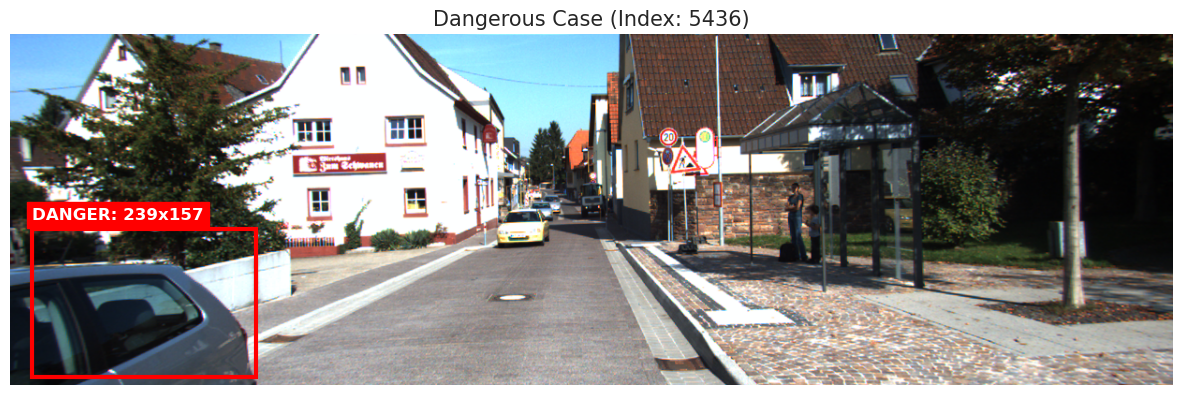

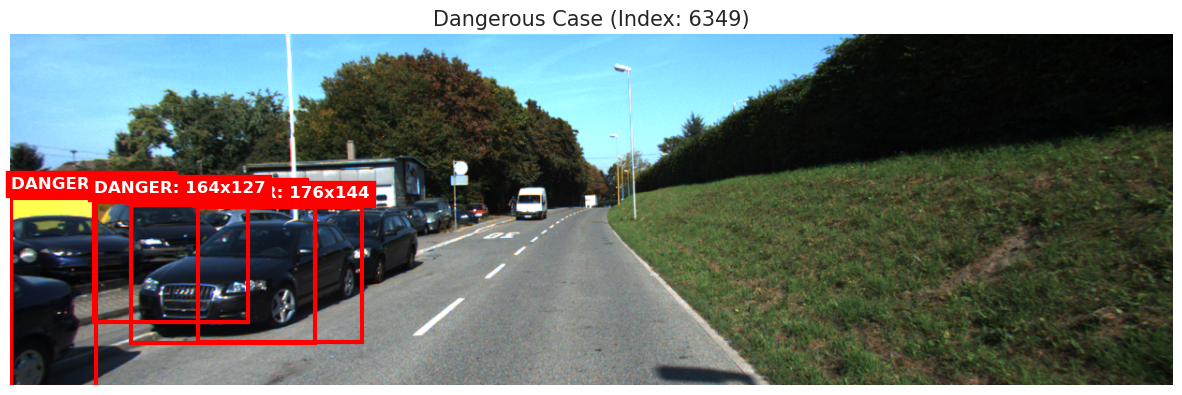

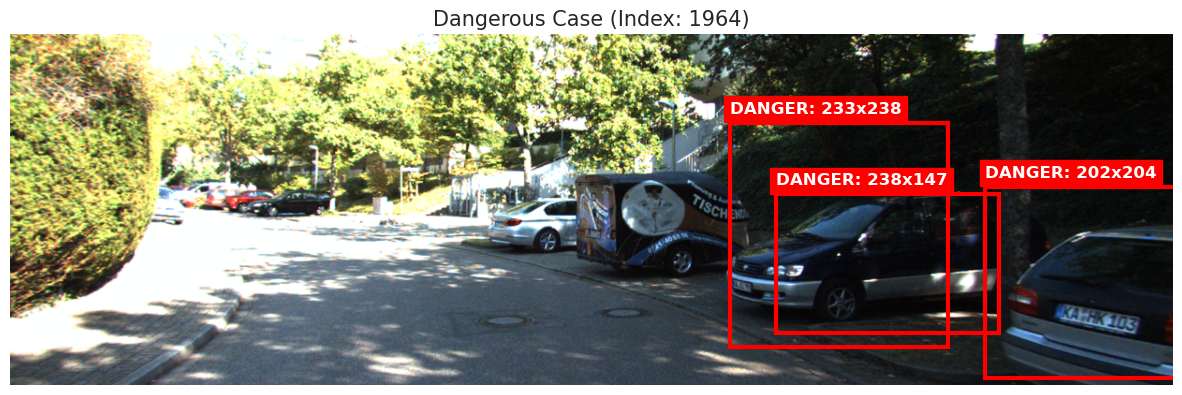

In [21]:
# 예시 출력
def visualize_truncated_cases(model, decoder, dataset, device):
    model.eval()
    found_count = 0
    indices = torch.randperm(len(dataset)).tolist()
    
    for idx in indices:
        if found_count >= 3: break
            
        # 이미 transform에서 정규화가 된 상태로 나옴
        image_tensor, _ = dataset[idx]
        input_tensor = image_tensor.unsqueeze(0).to(device)
        
        with torch.no_grad():
            predictions = model(input_tensor)
            decoded = decoder(input_tensor, predictions)[0]
            
        boxes, _, labels = decoded
        has_dangerous = False
        
        # --- 시각화를 위해 정규화 해제 (De-normalization) ---
        img_show = image_tensor.permute(1, 2, 0).cpu().numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_show = std * img_show + mean  # 원래 색상 복원
        img_show = np.clip(img_show, 0, 1) # [0, 1] 사이로 클리핑
        
        fig, ax = plt.subplots(1, figsize=(15, 7))
        ax.imshow(img_show)
        
        # 박스 그리기
        for i in range(len(boxes)):
            box = boxes[i].cpu().numpy()
            label_name = ID_TO_CLASS[labels[i].item()]
            w, h = box[2]-box[0], box[3]-box[1]
            
            # 위험 사례 조건 (300px 미만 차량이 하단에 위치)
            if label_name == 'Car' and (w < 300 or h < 300) and (box[3] > 300):
                has_dangerous = True
                rect = mpatches.Rectangle((box[0], box[1]), w, h, 
                                       linewidth=3, edgecolor='red', facecolor='none')
                ax.add_patch(rect)
                ax.text(box[0], box[1]-10, f"DANGER: {int(w)}x{int(h)}", 
                        color='white', backgroundcolor='red', fontweight='bold')
        
        if has_dangerous:
            plt.title(f"Dangerous Case (Index: {idx})", fontsize=15)
            plt.axis('off')
            plt.show()
            found_count += 1
        else:
            plt.close()

visualize_truncated_cases(model, decoder, test_dataset, device)

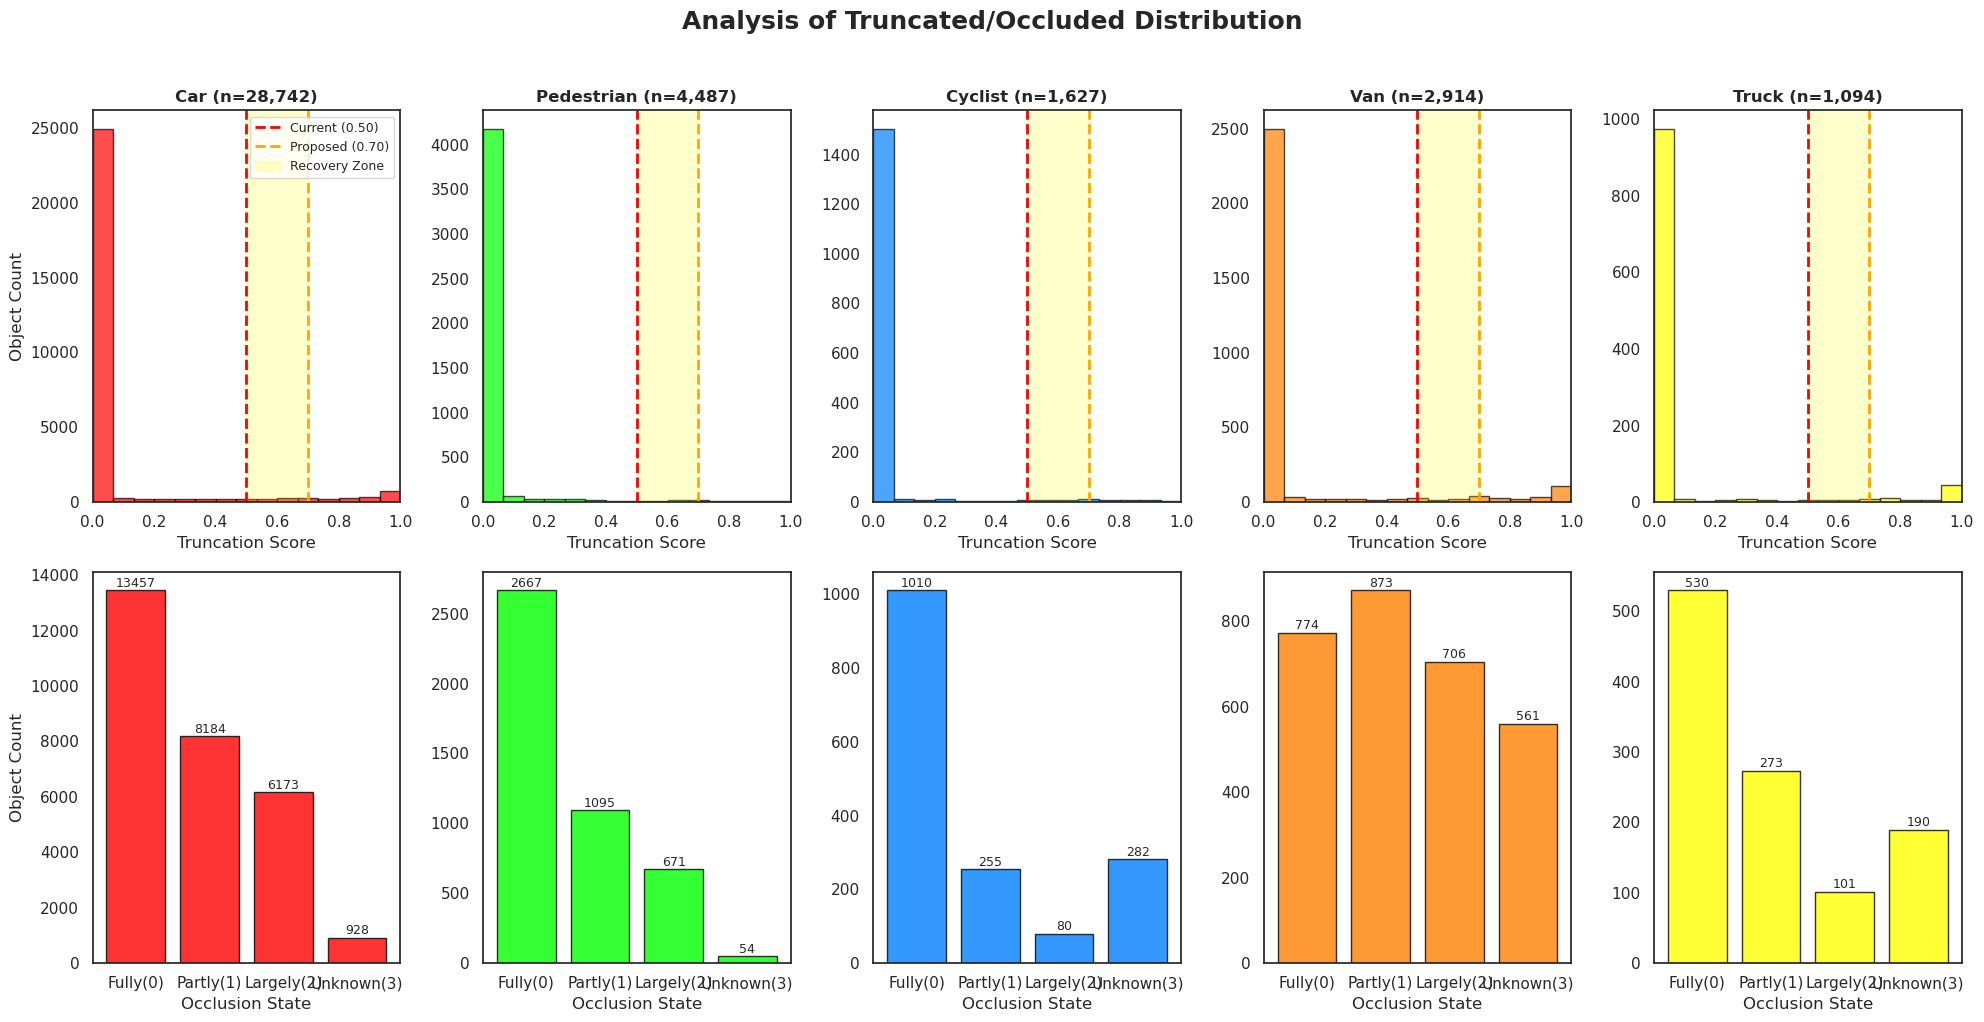

시각화 완료 및 저장: eda_truncated_occluded_en.png


In [22]:
# Truncated / Occluded 분포 확인
def plot_truncated_occluded(records):
    # 분석 대상 클래스 설정
    main_classes = ['Car', 'Pedestrian', 'Cyclist', 'Van', 'Truck']
    fig, axes = plt.subplots(2, len(main_classes), figsize=(20, 10))

    for col, cls in enumerate(main_classes):
        # 1. 클래스별 데이터 추출 및 타입 캐스팅 (안정성 확보)
        cls_recs = [r for r in records if r.get('class') == cls]
        trunc_vals = [float(r['truncated']) for r in cls_recs if 'truncated' in r]
        occ_vals = [int(r['occluded']) for r in cls_recs if 'occluded' in r]

        # 2. 색상 정규화 (Matplotlib 255 범위 에러 해결)
        raw_color = CLASS_COLORS.get(cls, (128, 128, 128))
        normalized_color = [v/255.0 for v in raw_color]

        # 데이터가 없는 클래스 예외 처리
        if not cls_recs:
            axes[0, col].text(0.5, 0.5, 'No Data', ha='center')
            axes[1, col].text(0.5, 0.5, 'No Data', ha='center')
            continue

        # --- 상단: Truncated 히스토그램 (35번 사례: 잘린 객체 분석용) ---
        axes[0, col].hist(trunc_vals, bins=15, color=normalized_color, 
                          edgecolor='black', alpha=0.7)
        
        # 가이드 라인 설정 (0.5에서 0.7로 완화하는 근거 시각화)
        axes[0, col].axvline(0.50, color='red', linestyle='--', lw=2, label='Current (0.50)')
        axes[0, col].axvline(0.70, color='orange', linestyle='--', lw=2, label='Proposed (0.70)')
        
        # 35번 사례 같은 객체들이 구제되는 'Safety Recovery Zone' 표시
        axes[0, col].axvspan(0.5, 0.7, color='yellow', alpha=0.2, label='Recovery Zone')
        
        axes[0, col].set_title(f'{cls} (n={len(cls_recs):,})', fontsize=12, fontweight='bold')
        axes[0, col].set_xlim(0, 1.0)
        axes[0, col].set_xlabel('Truncation Score') # 잘림 정도
        
        if col == 0:
            axes[0, col].set_ylabel('Object Count', fontsize=12)
            axes[0, col].legend(fontsize=9, loc='upper right')

        # --- 하단: Occluded 막대그래프 ---
        occ_cnt = Counter(occ_vals)
        # KITTI 기준: 0=Fully visible, 1=Partly, 2=Largely, 3=Unknown
        occ_labels = ['Fully(0)', 'Partly(1)', 'Largely(2)', 'Unknown(3)']
        occ_counts = [occ_cnt.get(i, 0) for i in range(4)]
        
        bars = axes[1, col].bar(occ_labels, occ_counts, color=normalized_color, 
                                edgecolor='black', alpha=0.8)
        
        # 막대 위에 수치 표시 (가독성 향상)
        for bar in bars:
            height = bar.get_height()
            axes[1, col].text(bar.get_x() + bar.get_width()/2., height + 1,
                              f'{int(height)}', ha='center', va='bottom', fontsize=9)
            
        axes[1, col].set_xlabel('Occlusion State') # 가려짐 상태
        if col == 0:
            axes[1, col].set_ylabel('Object Count', fontsize=12)

    # 메인 타이틀 (영문으로 깨짐 방지)
    fig.suptitle('Analysis of Truncated/Occluded Distribution', 
                 fontsize=18, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    # 영문 버전 파일명으로 저장
    plt.savefig('eda_truncated_occluded_en.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('시각화 완료 및 저장: eda_truncated_occluded_en.png')

# 함수 호출
plot_truncated_occluded(records)

##### **Truncated / Occluded 분포 해석**

**1. Truncation (상단 히스토그램: 객체 잘림 정도)**  

Recovery Zone (0.5 ~ 0.7): 노란색으로 강조된 이 구간에 상당수의 Car, Van, Truck 데이터가 존재한다. 기존의 0.5 임계치를 유지할 경우, 이 구간에 속한 차량들은 화면 가장자리에 있다는 이유로 모두 무시되고, 그 결과로 사고 위험이 발생한다. 임계치를 **0.7로 완화**함으로써, 385번 사례와 같이 일부가 잘린 채로 주행 경로에 침범하는 차량들을 안전하게 탐지 범위에 포함시킬 수 있을 것으로 기대한다.  

**2. Occlusion (하단 막대그래프: 객체 가려짐 상태)**  

Car 클래스의 경우, 'Partly(1)'와 'Largely(2)' 상태의 객체가 도합 14,000건 이상으로 매우 높은 비중을 차지한다. 가려진 객체는 겉보기에 크기가 작아 보일 수 있으므로, 단순히 픽셀 크기로만 필터링하지 말고 가려짐 상태를 고려한 별도의 예외 처리 로직이 반드시 필요하다.

### 바운딩 박스 크기

/tmp/ipykernel_1054/3815512946.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(height_data, labels=main_classes, patch_artist=True, notch=False)


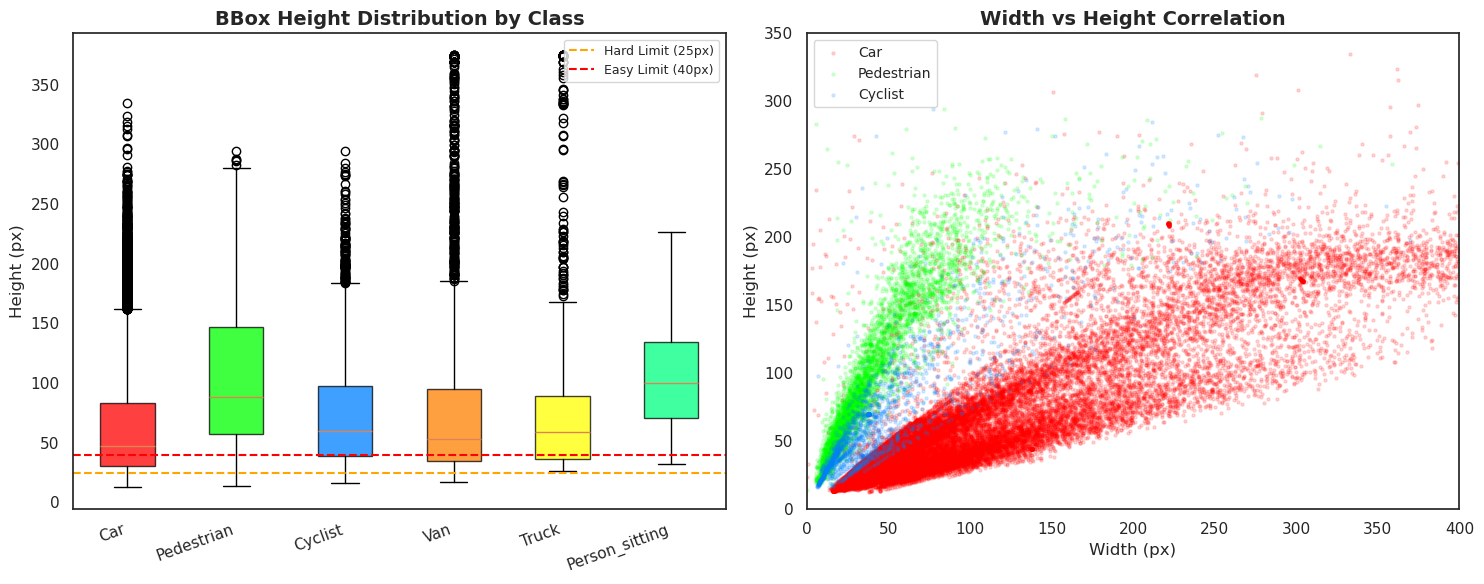

시각화 완료 및 저장: eda_bbox_sizes_en.png


In [23]:
def plot_bbox_sizes(records):
    main_classes = ['Car', 'Pedestrian', 'Cyclist', 'Van', 'Truck', 'Person_sitting']
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # --- 1. 왼쪽 박스플롯: BBox 높이 비교 ---
    height_data = [[r['h_box'] for r in records if r['class'] == c] for c in main_classes]
    
    # notch=False로 설정하여 깔끔한 박스 표시
    bp = axes[0].boxplot(height_data, labels=main_classes, patch_artist=True, notch=False)
    
    # 클래스별 색상 적용 (정규화 포함)
    for patch, cls in zip(bp['boxes'], main_classes):
        raw_color = CLASS_COLORS.get(cls, (128, 128, 128))
        normalized_color = [v/255.0 for v in raw_color] # 255 에러 방지
        patch.set_facecolor(normalized_color)
        patch.set_alpha(0.75)

    axes[0].set_title('BBox Height Distribution by Class', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Height (px)')
    axes[0].set_xticklabels(main_classes, rotation=20, ha='right')
    
    # KITTI 기준선 추가 (영문 레이블)
    axes[0].axhline(25, color='orange', linestyle='--', lw=1.5, label='Hard Limit (25px)')
    axes[0].axhline(40, color='red',    linestyle='--', lw=1.5, label='Easy Limit (40px)')
    axes[0].legend(fontsize=9)

    # --- 2. 오른쪽 산점도: BBox 높이 vs 너비 ---
    for cls in ['Car', 'Pedestrian', 'Cyclist']:
        cls_recs = [r for r in records if r['class'] == cls]
        xs = [r['w_box'] for r in cls_recs]
        ys = [r['h_box'] for r in cls_recs]
        
        raw_color = CLASS_COLORS.get(cls, (128, 128, 128))
        normalized_color = [v/255.0 for v in raw_color]
        
        axes[1].scatter(xs, ys, alpha=0.15, s=5,
                        color=normalized_color, label=cls)

    axes[1].set_xlabel('Width (px)')
    axes[1].set_ylabel('Height (px)')
    axes[1].set_title('Width vs Height Correlation', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=10)
    
    # 분포 시각화를 위한 축 범위 제한
    axes[1].set_xlim(0, 400)
    axes[1].set_ylim(0, 350)

    plt.tight_layout()
    plt.savefig('eda_bbox_sizes_en.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('시각화 완료 및 저장: eda_bbox_sizes_en.png')

# 함수 실행
plot_bbox_sizes(records)

##### **BBox 크기 분포 그래프 분석**

**1. 바운딩 박스 높이**  

왼쪽 박스플롯을 보면 대부분의 객체는 'Easy' 기준선 위에 존재한다. 특히나 Car, Pedestrian, Van 등 주요 클래스의 평균 높이(중앙선)가 빨간선(40px, Easy 기준)보다 훨씬 높게 형성되어 있다. 즉, 시스템이 처리해야 할 대부분의 위협 요소가 충분히 탐지 가능한 크기임을 의미한다.

**2. 바운딩 박스 너비 vs. 높이 산점도**

오른쪽 산점도(Correlation)를 보면, Height가 200px을 넘는 객체들도 Width는 300px에 못 미치는 경우가 많다. 만약 너비나 높이가 300px 이상이어야만 정지한다면, 화면의 절반을 차지하는 보행자나 대형 트럭조차 '작은 객체'로 간주되어 통과될 수 있다.  

또한 Pedestrian(연두색)은 위로 길게 뻗어 있고, Car(빨간색)는 옆으로 넓게 퍼지는 군집을 이루는데, 단순히 크기만 볼 것이 아니라 클래스별로 다른 크기 임계치를 적용해야 함을 알 수 있다.

### 객체 근접도 분포

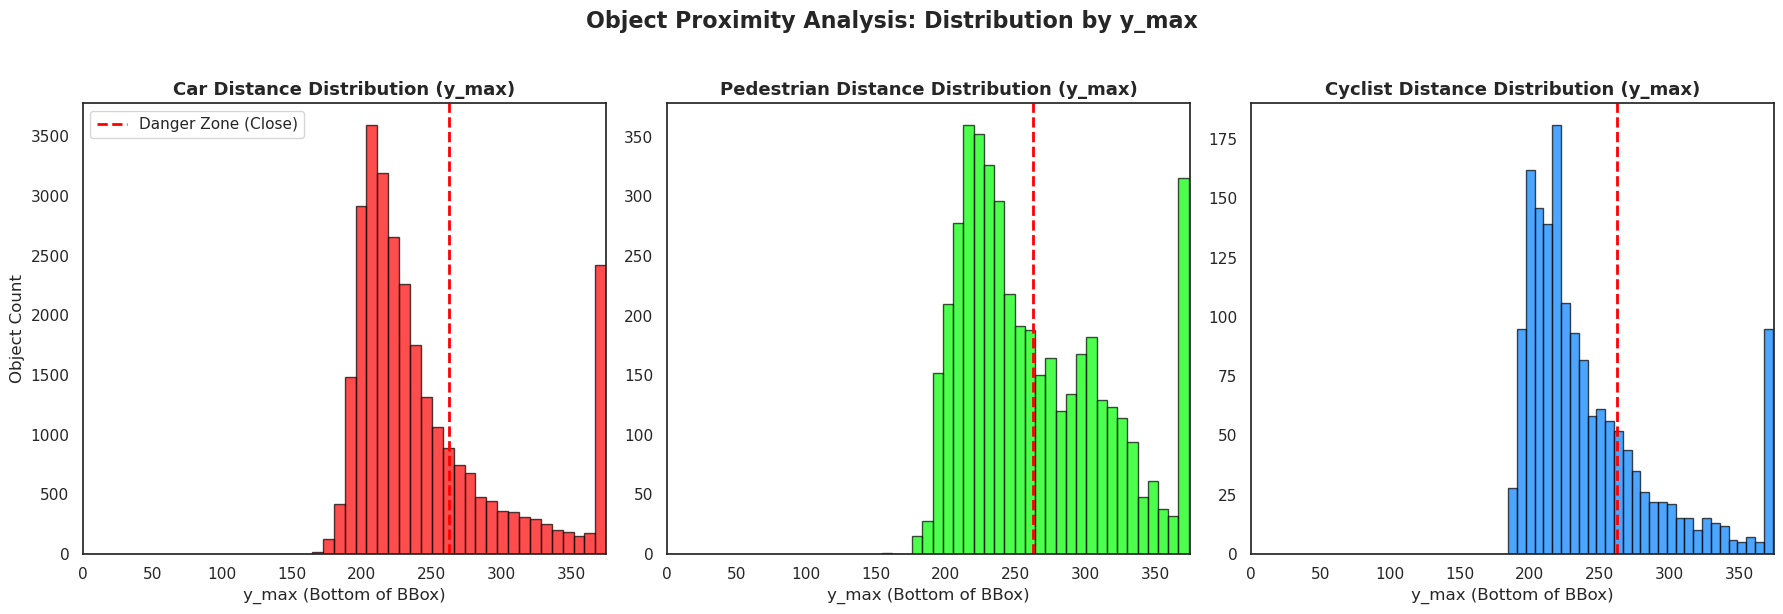

시각화 완료 및 저장: eda_distance_ymax.png


In [24]:
# 거리 대비 탐지율 확인
def plot_distance_distribution(records):
    # 분석 대상 클래스
    main_classes = ['Car', 'Pedestrian', 'Cyclist']
    fig, axes = plt.subplots(1, len(main_classes), figsize=(18, 6))
    
    # 이미지 높이 (KITTI 기준 보통 375px 내외)
    img_height = 375 

    for i, cls in enumerate(main_classes):
        cls_recs = [r for r in records if r.get('class') == cls]
        # y2 (bbox 하단 좌표)를 거리의 대용치로 사용
        y_max_vals = [r.get('y2', 0) for r in cls_recs]
        
        # 색상 정규화
        raw_color = CLASS_COLORS.get(cls, (128, 128, 128))
        normalized_color = [v/255.0 for v in raw_color]
        
        # 히스토그램 (가로축이 y_max)
        axes[i].hist(y_max_vals, bins=30, color=normalized_color, edgecolor='black', alpha=0.7)
        
        # 위험 구역 설정 (화면 하단 30% 영역을 가깝고 위험한 곳으로 가정)
        danger_zone = img_height * 0.7
        axes[i].axvline(danger_zone, color='red', linestyle='--', lw=2, label='Danger Zone (Close)')
        
        axes[i].set_title(f'{cls} Distance Distribution (y_max)', fontsize=13, fontweight='bold')
        axes[i].set_xlabel('y_max (Bottom of BBox)')
        axes[i].set_xlim(0, img_height)
        
        if i == 0:
            axes[i].set_ylabel('Object Count')
            axes[i].legend()

    fig.suptitle('Object Proximity Analysis: Distribution by y_max', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('eda_distance_ymax.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('시각화 완료 및 저장: eda_distance_ymax.png')

# 함수 실행
plot_distance_distribution(records)

##### **근접도 분포 그래프 해석**

**1. y_max의 물리적 의미**

- 화면 하단 = 근거리: 카메라 기하학 구조상 y_max(BBox의 하단 좌표) 수치가 클수록 물체가 내 차량과 물리적으로 가깝다는 것을 의미한다.

- Danger Zone (빨간 점선): 그래프의 빨간 점선 오른쪽 영역은 내 차와 매우 가까워 즉각적인 대응이 필요한 고위험 근접 구역이다.


**2. 클래스별 분포 특징**

- Car: Danger Zone 진입 전후로 객체 수가 급격히 완만해지지만, 화면 가장 하단 (y_max ~ 375)에서 다시 솟구치는 분포를 보인다. 내 차 바로 옆이나 앞에 바짝 붙은 차량들이 상당수 존재함을 뜻하는 결과이다.

- Pedestrian: 보행자는 Danger Zone 이후에도 분포가 길게 늘어져 있으며, 특히 최하단 영역의 비중이 높다. 이는 보행자가 갑자기 차량 근처로 근접하는 상황이 빈번함을 뜻한다.

### 난이도 분포

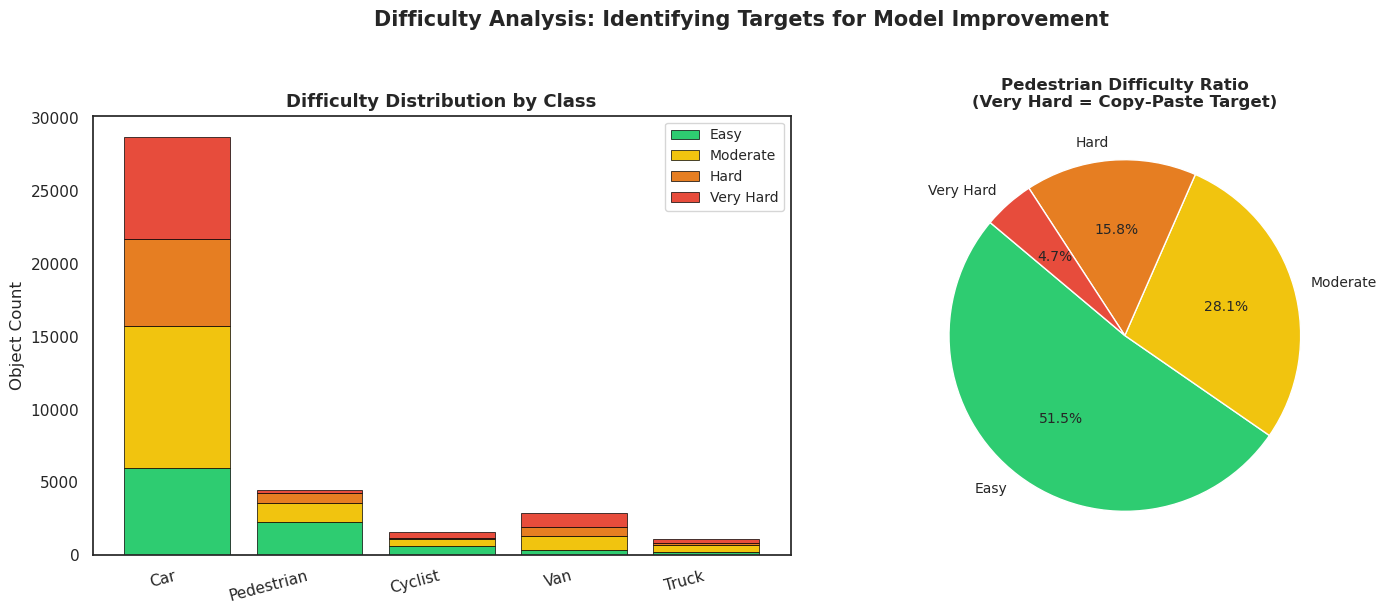

시각화 완료 및 저장: eda_difficulty_en.png


In [25]:
# 물체 식별 난이도 분포 확인
def plot_difficulty_distribution(records):
    main_classes = ['Car', 'Pedestrian', 'Cyclist', 'Van', 'Truck']
    diff_order   = ['Easy', 'Moderate', 'Hard', 'Very Hard']
    diff_colors  = {'Easy': '#2ecc71', 'Moderate': '#f1c40f', 
                    'Hard': '#e67e22', 'Very Hard': '#e74c3c'}
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # 1. Stacked Bar Chart: Difficulty by Class
    diff_by_cls = defaultdict(lambda: Counter())
    for r in records:
        if r.get('class') in main_classes:
            diff_by_cls[r['class']][r.get('difficulty', 'Unknown')] += 1

    x = np.arange(len(main_classes))
    bottom = np.zeros(len(main_classes))

    for diff in diff_order:
        vals = [diff_by_cls[c][diff] for c in main_classes]
        axes[0].bar(x, vals, bottom=bottom, label=diff, 
                    color=diff_colors[diff], edgecolor='black', linewidth=0.5)
        bottom += np.array(vals)

    axes[0].set_xticks(x)
    axes[0].set_xticklabels(main_classes, rotation=15, ha='right')
    axes[0].set_title('Difficulty Distribution by Class', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Object Count')
    axes[0].legend(fontsize=10)

    # 2. Pie Chart: Pedestrian Difficulty Ratio (The Copy-Paste Target)
    ped_diff = Counter(r.get('difficulty', 'Unknown') for r in records if r.get('class') == 'Pedestrian')
    axes[1].pie([ped_diff[d] for d in diff_order], 
                labels=diff_order, 
                colors=[diff_colors[d] for d in diff_order],
                autopct='%1.1f%%', startangle=140,
                textprops={'fontsize': 10})
    axes[1].set_title('Pedestrian Difficulty Ratio\n(Very Hard = Copy-Paste Target)', fontsize=12, fontweight='bold')

    plt.suptitle('Difficulty Analysis: Identifying Targets for Model Improvement', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('eda_difficulty_en.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('시각화 완료 및 저장: eda_difficulty_en.png')

plot_difficulty_distribution(records)

##### **난이도 분포 그래프 해석**

- **Moderate/Hard의 높은 비중**: 특히 Car 클래스에서 Moderate와 Hard가 차지하는 비중이 상당하다. 이는 모델이 단순히 눈에 잘 보이는 차만 상대하는 게 아니라, 복잡한 상황에 놓인 객체들을 많이 다뤄야 한다는 뜻이다.

- **Pedestrian 타깃**: 보행자의 경우 Very Hard가 4.7%에 달한다. 숫자는 적어 보이나, 자율주행 상황에서 예상치 못한 사고를 막기 위해 증강 기법으로 학습시켜야 함을 재확인했다.

### 개선안 정리

**1. 탐지 임계치(Threshold) 최적화**

- **Truncation 완화 (0.5 → 0.7)**: 화면 가장자리에 걸쳐 30%만 보이는 차량(Case #35 등)도 탐지 대상에 강제로 포함한다. 옆 차선이나 교차로 진입 차량 등  포착에 필수적이다.

- **Occlusion 예외 처리**: 가려짐 수치가 Largely(2)인 객체는 면적이 작더라도 필터링하지 않고 모델의 우선순위를 높인다.


**2. 크기 필터링 전략 수정**

- **높이(Height) 중심 필터**: 너비(Width) 300px 보다, 거리와 상관관계가 높은 Height 40px(Easy 기준)을 기본 탐지선으로 설정한다.

- **근접도(y_max) 연동**: 객체 근접도 분포 분석에 따라, y_max가 Danger Zone(화면 하단)에 위치한 객체는 높이가 25px (Hard 기준) 미만이라도 절대 무시하지 않는다.


**3. 데이터 증강(Augmentation) 전략**

- **Copy-Paste 기법 적용**: 난이도 분포에서 확인된 Very Hard 및 Hard 등급의 Pedestrian(보행자) 객체를 다양한 배경에 복사 및 붙여넣기 하여 부족한 학습 샘플을 강제로 보충한다.

## 6. 학습 데이터 준비

### 데이터셋 클래스 정의

In [26]:
class KITTIDatasetImproved(Dataset):
    """
    개선된 KITTI 객체 탐지 데이터셋
    
    [핵심 변경 사항]
    - truncated_threshold=0.70: 화면 끝에 걸린(Hard 수준) 차량 탐지를 위해 학습 포함 범위 확대
    - Occlusion 예외 처리: 가려짐이 심한(Largely, 2) 객체라도 위험도가 높으므로 학습 데이터 보존
    - 근접도(y_max) 연동 필터: 
        1) Danger Zone(화면 하단) 객체는 높이 25px까지 허용 (기존 40px)
        2) 일반 구역은 노이즈 제거를 위해 40px 기준 적용
    - min_bbox_height=10.0: 데이터 무결성을 위해 10px 미만 초소형 노이즈만 최종 제외
    """
    ALL_CLASSES = ['Car', 'Van', 'Truck', 'Pedestrian', 'Person_sitting', 'Cyclist', 'Tram', 'Misc', 'DontCare']

    def __init__(
        self,
        img_dir:             str,
        label_dir:           str,
        classes:             Optional[List[str]] = None,
        exclude_dontcare:    bool  = True,
        truncated_threshold: float = 0.70,   # 변경 사항: 0.50 → 0.70
        occluded_threshold:  int   = 2,
        min_bbox_height:     float = 10.0,
    ):
        self.img_dir             = img_dir
        self.label_dir           = label_dir
        self.exclude_dontcare    = exclude_dontcare
        self.truncated_threshold = truncated_threshold
        self.occluded_threshold  = occluded_threshold
        self.min_bbox_height     = min_bbox_height

        self.classes      = [c for c in self.ALL_CLASSES if c != 'DontCare'] if classes is None else classes
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        self.idx_to_class = {i: c for c, i in self.class_to_idx.items()}
        self.image_files  = self._get_image_files()

        print(f'KITTIDatasetImproved 초기화 (안전 가이드라인 적용):')
        print(f'  이미지 수          : {len(self.image_files)}')
        print(f'  truncated_threshold: {truncated_threshold}  (v1=0.50 → v2=0.70)')
        print(f'  Danger Zone 연동 필터 및 Occlusion 예외 로직 활성화')

    def _get_image_files(self):
        files = []
        for fname in sorted(os.listdir(self.img_dir)):
            if not (fname.endswith('.png') or fname.endswith('.jpg')): continue
            lpath = os.path.join(self.label_dir, fname.replace('.png', '.txt').replace('.jpg', '.txt'))
            if os.path.exists(os.path.join(self.img_dir, fname)) and os.path.exists(lpath):
                files.append(fname)
        return files

    def _parse_label(self, label_path):
        boxes, labels = [], []
        if not os.path.exists(label_path):
            return np.zeros((0, 4), dtype=np.float32), np.zeros((0,), dtype=np.int64)
        
        # 변경 사항: 근접도(y_max) 분석에 따른 Danger Zone 기준 설정 (객체 근접도 분포 반영)
        DANGER_ZONE_Y = 300 
        
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 15: continue
                cls_name = parts[0]
                if self.exclude_dontcare and cls_name == 'DontCare': continue
                if cls_name not in self.class_to_idx: continue
                
                truncated = float(parts[1])
                occluded  = int(parts[2])
                x1, y1, x2, y2 = map(float, parts[4:8])
                
                # Truncation 필터
                if truncated > self.truncated_threshold: continue   # ★ 핵심 필터
                
                # Occlusion 예외 및 근접도 연동 높이 필터링
                # 변경 사항: [Occlusion 예외 처리] 가려짐 수치가 Largely(2)인 위험 객체는 보존
                # 변경 사항: [근접도(y_max) 연동] Danger Zone(화면 하단)에 있으면 min_h 기준 완화
                
                h = y2 - y1
                y_max = y2
                
                # Danger Zone(y_max > 300)에 있거나 Largely Occluded(2)인 경우 25px까지 허용
                # 그 외 일반 구역은 노이즈 제거를 위해 40px 기준 적용
                dynamic_min_h = 25.0 if (y_max > DANGER_ZONE_Y or occluded >= 2) else 40.0
                
                # 만약 동적 기준보다도 작다면 최종적으로 객체 제외
                if h < dynamic_min_h:
                    # 데이터셋 초기 설정값(min_bbox_height=10)보다도 작은 노이즈는 무조건 제거
                    if h < self.min_bbox_height: continue
                    # 위 조건에 해당하지 않는 일반 작은 객체는 탈락
                    continue

                # Occlusion 임계치 체크 (단, Danger Zone에 있는 위험 객체는 가려졌더라도 통과)
                if occluded > self.occluded_threshold and y_max <= DANGER_ZONE_Y:
                    continue

                boxes.append([x1, y1, x2, y2])
                labels.append(self.class_to_idx[cls_name])
                
        if not boxes:
            return np.zeros((0, 4), dtype=np.float32), np.zeros((0,), dtype=np.int64)
        return np.array(boxes, dtype=np.float32), np.array(labels, dtype=np.int64)

    def __len__(self): return len(self.image_files)

    def __getitem__(self, idx):
        fname      = self.image_files[idx]
        img_path   = os.path.join(self.img_dir, fname)
        label_path = os.path.join(self.label_dir, fname.replace('.png', '.txt').replace('.jpg', '.txt'))
        image      = Image.open(img_path).convert('RGB')
        boxes, labels = self._parse_label(label_path)
        return {'image': image, 'boxes': boxes, 'labels': labels, 'image_id': idx}

### 이미지 증강 기법 정의

In [27]:
# 기본 이미지 증강 정의

# 1. 개별 증강 클래스들은 기존 로직을 유지하되, 
# Copy-Paste와의 호환성을 위해 PIL 이미지 상태를 유지하도록 구성

class RandomHorizontalFlip:
    def __init__(self, p=0.5): self.p = p
    def __call__(self, image, target):
        if random.random() < self.p:
            image = TF.hflip(image)
            # PIL Image인지 확인 후 너비 계산
            w = image.size[0] if isinstance(image, Image.Image) else image.shape[-1]
            boxes = target['boxes'].copy()
            if len(boxes) > 0:
                boxes[:, [0, 2]] = w - boxes[:, [2, 0]]
                target['boxes'] = boxes
        return image, target

class ColorJitter:
    def __init__(self, brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1):
        self.brightness = brightness; self.contrast = contrast
        self.saturation = saturation; self.hue = hue
    def __call__(self, image, target):
        if isinstance(image, Image.Image):
            if self.brightness: image = TF.adjust_brightness(image, random.uniform(1-self.brightness, 1+self.brightness))
            if self.contrast:   image = TF.adjust_contrast(image,   random.uniform(1-self.contrast,   1+self.contrast))
            if self.saturation: image = TF.adjust_saturation(image, random.uniform(1-self.saturation, 1+self.saturation))
            if self.hue:        image = TF.adjust_hue(image,        random.uniform(-self.hue, self.hue))
        return image, target

class Resize:
    def __init__(self, size): self.size = size
    def __call__(self, image, target):
        ow, oh = image.size if isinstance(image, Image.Image) else (image.shape[-1], image.shape[-2])
        image  = TF.resize(image, self.size)
        nh, nw = self.size
        boxes  = target['boxes'].copy()
        if len(boxes) > 0:
            boxes[:, [0, 2]] *= nw/ow; boxes[:, [1, 3]] *= nh/oh
            target['boxes'] = boxes
        return image, target

class Compose:
    def __init__(self, transforms): self.transforms = transforms
    def __call__(self, image, target):
        for t in self.transforms: image, target = t(image, target)
        return image, target

# 2. 증강 목록 정의 (ToTensor, Normalize를 제거!)
# 변경 사항: Copy-Paste를 위해 PIL 이미지 상태로 반환하도록 수정

def get_train_transforms(img_size=(384, 640)):
    """학습용: 랜덤 뒤집기, 색상 변조, 크기 조절만 수행 (PIL 반환)"""
    return Compose([
        RandomHorizontalFlip(p=0.3),
        ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
        Resize(img_size)
    ])

def get_val_transforms(img_size=(384, 640)):
    """검증용: 크기 조절만 수행 (PIL 반환)"""
    return Compose([Resize(img_size)])

In [28]:
# 변경 사항: Copy-Paste 증강 기법 추가
class CopyPasteAugmentation:
    """
    희소 클래스(Pedestrian 등) bbox를 다른 이미지에 복사 및 붙여넣어 샘플 수 증가 -> 데이터 불균형 해소
    배치 단위로 적용 (train_one_epoch 내부에서 호출)
    """
    def __init__(self, rare_class_ids=[3, 4, 5], paste_prob=0.5, max_paste=3, min_overlap_iou=0.1):
        self.rare_class_ids = set(rare_class_ids)
        self.paste_prob = paste_prob
        self.max_paste = max_paste
        self.min_overlap_iou = min_overlap_iou

    def _iou_single(self, box, boxes):
        if len(boxes) == 0: return np.array([])
        ix1 = np.maximum(box[0], boxes[:, 0]); iy1 = np.maximum(box[1], boxes[:, 1])
        ix2 = np.minimum(box[2], boxes[:, 2]); iy2 = np.minimum(box[3], boxes[:, 3])
        inter = np.maximum(ix2 - ix1, 0) * np.maximum(iy2 - iy1, 0)
        a1 = (box[2] - box[0]) * (box[3] - box[1])
        a2 = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
        return inter / np.maximum(a1 + a2 - inter, 1e-8)

    def _find_loc(self, pw, ph, iw, ih, exist_boxes, n=10):
        if pw >= iw or ph >= ih: return None
        for _ in range(n):
            x = random.randint(0, iw - pw); y = random.randint(0, ih - ph)
            cand = np.array([x, y, x + pw, y + ph])
            # 기존 박스들과 너무 많이 겹치지 않는 위치 선정
            if len(exist_boxes) == 0 or self._iou_single(cand, exist_boxes).max() < self.min_overlap_iou:
                return x, y
        return None

    def apply_to_batch(self, images, targets):
        """
        images: PIL 이미지 리스트
        targets: {'boxes': numpy, 'labels': numpy} 리스트
        """
        # 배치 내에 희소 객체를 가진 이미지(Donor) 찾기
        donor_pool = [i for i, t in enumerate(targets) if any(l in self.rare_class_ids for l in t['labels'])]
        if not donor_pool: return images, targets

        aug_imgs = [img.copy() for img in images]
        aug_tgts = [copy.deepcopy(t) for t in targets]

        for bi in range(len(images)):
            if random.random() > self.paste_prob: continue
            
            base_img, base_tgt = aug_imgs[bi], aug_tgts[bi]
            iw, ih = base_img.size
            
            for _ in range(self.max_paste):
                di = random.choice(donor_pool)
                dimg, dtgt = images[di], targets[di]
                
                # Donor 이미지에서 희소 객체들만 선택
                rare_idx = [i for i, l in enumerate(dtgt['labels']) if l in self.rare_class_ids]
                if not rare_idx: continue
                
                pick = random.choice(rare_idx)
                box = dtgt['boxes'][pick].astype(int)
                lbl = dtgt['labels'][pick]
                
                x1, y1, x2, y2 = box
                pw, ph = x2 - x1, y2 - y1
                if pw < 5 or ph < 5: continue # 너무 작은 박스 제외
                
                loc = self._find_loc(pw, ph, iw, ih, base_tgt['boxes'])
                if loc is None: continue
                
                px, py = loc
                # PIL Crop & Paste 수행
                cropped_obj = dimg.crop((x1, y1, x2, y2))
                base_img.paste(cropped_obj, (px, py))
                
                # 타겟 정보 업데이트
                new_box = np.array([[px, py, px + pw, py + ph]], dtype=np.float32)
                if len(base_tgt['boxes']) > 0:
                    base_tgt['boxes'] = np.vstack([base_tgt['boxes'], new_box])
                else:
                    base_tgt['boxes'] = new_box
                base_tgt['labels'] = np.append(base_tgt['labels'], lbl)
                
            aug_imgs[bi] = base_img
            aug_tgts[bi] = base_tgt
            
        return aug_imgs, aug_tgts

### 데이터 로더 정의 (WeightedRandomSampler)

변경 사항: 
 - `shuffle=True` → `WeightedRandomSampler(rare_weight=4.0)`
 - 속도 개선: `num_workers=4`, `batch_size=16`, `img_size=384×640`

In [29]:
# 수정 사항: 텐서 변환을 하지 않고 리스트 형태로 반환
def collate_fn(batch):
    """
    Copy-Paste 증강을 위해 이미지를 텐서로 stack하지 않고 
    PIL 이미지 객체의 리스트 형태로 반환
    """
    images = [b['image'] for b in batch]
    targets = [{
        'boxes': b['boxes'],      # Copy-Paste를 위해 numpy 상태 유지 선호
        'labels': b['labels'], 
        'image_id': b['image_id']
    } for b in batch]
    return images, targets

class TransformedDataset(Dataset):
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform
    def __len__(self): 
        return len(self.dataset)
    def __getitem__(self, idx):
        s = self.dataset[idx]
        img, tgt = s['image'], {'boxes': s['boxes'], 'labels': s['labels'], 'image_id': s['image_id']}
        if self.transform: 
            img, tgt = self.transform(img, tgt)
        return {'image': img, 'boxes': tgt['boxes'], 'labels': tgt['labels'], 'image_id': tgt['image_id']}

# 샘플 가중치 계산
def compute_sample_weights(dataset, rare_weight=4.0, medium_weight=2.0, common_weight=1.0):
    weights = []
    for i in range(len(dataset)):
        label_set = set(dataset[i]['labels'])
        if label_set & RARE_IDS:    weights.append(rare_weight)
        elif label_set & MEDIUM_IDS: weights.append(medium_weight)
        else:                        weights.append(common_weight)
    return weights

def get_train_dataloader(img_dir, label_dir, batch_size=16, num_workers=4,
                         img_size=(384, 640), rare_weight=4.0):
    base_ds = KITTIDatasetImproved(img_dir=img_dir, label_dir=label_dir)
    # get_train_transforms는 이제 ToTensor/Normalize가 없는 상태
    ds = TransformedDataset(base_ds, get_train_transforms(img_size))
    
    weights = compute_sample_weights(base_ds, rare_weight=rare_weight)
    sampler = WeightedRandomSampler(weights, num_samples=len(ds), replacement=True)
    
    return DataLoader(
        ds, 
        batch_size=batch_size, 
        sampler=sampler,
        num_workers=num_workers, 
        collate_fn=collate_fn,  # 수정된 collate_fn 적용
        pin_memory=False        # PIL 리스트 반환 시 False가 안전 (Tensor stack 이후에 True 권장)
    )

def get_val_dataloader(img_dir, label_dir, batch_size=16, num_workers=4, img_size=(384, 640)):
    base_ds = KITTIDatasetImproved(img_dir=img_dir, label_dir=label_dir)
    ds = TransformedDataset(base_ds, get_val_transforms(img_size))
    
    return DataLoader(
        ds, 
        batch_size=batch_size, 
        shuffle=False,
        num_workers=num_workers, 
        collate_fn=collate_fn, 
        pin_memory=False
    )

## 7. 모델 학습

### Loss / LabelEncoder 정의

변경 사항:  
- FocalLoss `gamma=2.0` → `gamma=3.0`  
- `LabelEncoder` → `LabelEncoderWithClipping` (경계 anchor IoU 오류 방지)

In [30]:
class RetinaNetBoxLoss(nn.Module):
    def __init__(self, delta=1.0): super().__init__(); self._delta=delta
    def forward(self, y_true, y_pred):
        diff=y_true-y_pred; abs_diff=torch.abs(diff)
        loss=torch.where(abs_diff<self._delta, 0.5*diff**2, abs_diff-0.5)
        return torch.sum(loss, dim=-1)


class FocalLoss(nn.Module):
    """gamma=3.0 (v1=2.0) → 희소 클래스 loss 집중 강화"""
    def __init__(self, alpha=0.25, gamma=3.0):   # ★ gamma 2.0 → 3.0
        super().__init__(); self._alpha=alpha; self._gamma=gamma
    def forward(self, y_true, y_pred):
        ce    = F.binary_cross_entropy_with_logits(y_pred, y_true, reduction='none')
        probs = torch.sigmoid(y_pred)
        alpha = torch.where(y_true==1.0, self._alpha, 1.0-self._alpha)
        pt    = torch.where(y_true==1.0, probs, 1.0-probs)
        return alpha * torch.pow(1.0-pt, self._gamma) * ce


class RetinaNetLoss(nn.Module):
    def __init__(self, num_classes=8, alpha=0.25, gamma=3.0, delta=1.0):
        super().__init__()
        self._clf_loss    = FocalLoss(alpha, gamma)
        self._box_loss    = RetinaNetBoxLoss(delta)
        self._num_classes = num_classes
        print(f'RetinaNetLoss: alpha={alpha}, gamma={gamma} (v1=2.0 → v2=3.0)')

    def forward(self, y_true, y_pred):
        box_labels=y_true[:,:,:4]; cls_labels_raw=y_true[:,:,4]
        ignore_mask=(cls_labels_raw==-2); positive_mask=(cls_labels_raw>=0)
        cls_targets=F.one_hot(cls_labels_raw.clamp(min=0).long(), self._num_classes).float()
        cls_targets[~positive_mask]=0.0
        clf_loss = self._clf_loss(cls_targets, y_pred[:,:,4:]).sum(-1) * (~ignore_mask).float()
        box_loss = self._box_loss(box_labels, y_pred[:,:,:4]) * positive_mask.float()
        num_pos  = positive_mask.sum().clamp(min=1).float()
        return (clf_loss.sum() + box_loss.sum()) / num_pos

# ── Anchor 경계 클리핑 함수 ─────────────────────────────
def clip_anchors_to_image(anchors, image_height, image_width):
    """
    이미지 밖으로 나간 anchor를 경계로 클리핑 
    → truncated(0.7) 객체와의 IoU를 개선하여 검출력 향상
    """
    # anchors: [cx, cy, w, h]
    x1 = (anchors[:, 0] - anchors[:, 2] / 2).clamp(0, image_width)
    y1 = (anchors[:, 1] - anchors[:, 3] / 2).clamp(0, image_height)
    x2 = (anchors[:, 0] + anchors[:, 2] / 2).clamp(0, image_width)
    y2 = (anchors[:, 1] + anchors[:, 3] / 2).clamp(0, image_height)
    
    # 다시 [cx, cy, w, h] 형식으로 복구 (w, h가 0이 되지 않도록 아주 작은 값 clamp)
    return torch.stack([
        (x1 + x2) / 2, 
        (y1 + y2) / 2,
        (x2 - x1).clamp(min=1e-4), 
        (y2 - y1).clamp(min=1e-4)
    ], dim=-1)

# ── LabelEncoderWithClipping 클래스 ───────────────────────────
class LabelEncoderWithClipping:
    """
    Anchor 경계 클리핑 및 장치(Device) 자동 할당이 적용된 LabelEncoder
    """
    def __init__(self, box_variance=[0.1, 0.1, 0.2, 0.2]):
        self._anchor_box = AnchorBox() # 기존 정의된 AnchorBox 클래스 사용
        self._box_variance = torch.tensor(box_variance, dtype=torch.float32)

    def _compute_iou(self, b1, b2):
        """b1: anchors (N, 4), b2: gt_boxes (M, 4)"""
        lu = torch.maximum(b1[:, None, :2], b2[:, :2])
        rd = torch.minimum(b1[:, None, 2:], b2[:, 2:])
        inter = torch.clamp(rd - lu, min=0.0)
        inter_area = inter[:, :, 0] * inter[:, :, 1]
        a1 = (b1[:, 2] - b1[:, 0]) * (b1[:, 3] - b1[:, 1])
        a2 = (b2[:, 2] - b2[:, 0]) * (b2[:, 3] - b2[:, 1])
        return inter_area / torch.clamp(a1[:, None] + a2 - inter_area, min=1e-8)

    def _match(self, anchors, gt_boxes, match_iou=0.5, ignore_iou=0.4):
        # cxcywh -> x1y1x2y2
        anchor_corners = torch.cat([
            anchors[:, :2] - anchors[:, 2:] / 2, 
            anchors[:, :2] + anchors[:, 2:] / 2
        ], -1)
        
        iou = self._compute_iou(anchor_corners, gt_boxes)
        max_iou, matched = torch.max(iou, dim=1)
        
        pos = max_iou >= match_iou
        neg = max_iou < ignore_iou
        # ignore: positive도 아니고 negative도 아닌 구간 (-2로 마킹될 예정)
        return matched, pos.float(), (~(pos | neg)).float()

    def _box_target(self, anchors, gt_boxes, device):
        # GT: x1y1x2y2 -> cxcywh
        gt_cxcywh = torch.cat([
            (gt_boxes[:, :2] + gt_boxes[:, 2:]) / 2, 
            gt_boxes[:, 2:] - gt_boxes[:, :2]
        ], -1)
        
        # Target encoding
        tgt = torch.cat([
            (gt_cxcywh[:, :2] - anchors[:, :2]) / anchors[:, 2:],
            torch.log(gt_cxcywh[:, 2:] / anchors[:, 2:])
        ], -1)
        
        # variance 적용 시 장치 일치화
        return tgt / self._box_variance.to(device)

    def encode_batch(self, images, batch_boxes, batch_labels):
        """
        images: (B, C, H, W) Tensor
        batch_boxes: List of Tensors (batch size만큼의 리스트)
        batch_labels: List of Tensors
        """
        B, H, W = images.size(0), images.size(2), images.size(3)
        device = images.device  # ★ 핵심: 입력 이미지의 장치를 자동으로 추적
        
        # 1. Anchor 생성 및 장치 이동
        anchors = self._anchor_box.get_anchors(H, W).to(device)
        
        # 2. 클리핑 적용 (Truncated 객체 대응)
        anchors = clip_anchors_to_image(anchors, H, W)
        
        A = anchors.shape[0]
        encoded = torch.zeros((B, A, 5), device=device) # ★ 핵심: 결과 텐서도 동일 장치에 생성

        for i, (boxes, labels) in enumerate(zip(batch_boxes, batch_labels)):
            if len(boxes) == 0:
                encoded[i, :, 4] = -1.0 # 배경 처리
                continue
            
            # 박스와 라벨을 이미지와 동일한 장치로 이동
            boxes = boxes.to(device) if isinstance(boxes, torch.Tensor) else torch.tensor(boxes).to(device)
            labels = labels.to(device) if isinstance(labels, torch.Tensor) else torch.tensor(labels).to(device)
            
            # 매칭 로직
            matched, pos, ign = self._match(anchors, boxes)
            gt_matched = boxes[matched]
            
            # 박스 회귀 타겟 계산
            encoded[i, :, :4] = self._box_target(anchors, gt_matched, device)
            
            # 라벨 할당 (Positive: Label ID, Ignore: -2, Background: -1)
            encoded[i, :, 4] = torch.where(
                pos.bool(), 
                labels[matched].float(),
                torch.where(ign.bool(), torch.tensor(-2.0, device=device), torch.tensor(-1.0, device=device))
            )
            
        return encoded

### 체크포인트 유틸리티 함수 정의

In [31]:
def save_checkpoint(model, optimizer, epoch, loss, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save({'epoch': epoch, 'loss': loss,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict()}, path)

def load_checkpoint(model, optimizer, path, device='cuda'):
    ckpt = torch.load(path, map_location='cpu') # CPU로 먼저 로드
    model.load_state_dict(ckpt['model_state_dict'])
    model.to(device) # 현재 타겟 장치로 이동
    
    if optimizer: 
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        # Optimizer 내의 state 텐서들도 해당 장치로 이동시켜야 함
        for state in optimizer.state.values():
            for k, v in state.items():
                if isinstance(v, torch.Tensor):
                    state[k] = v.to(device)
                    
    print(f'체크포인트 로드 완료: epoch={ckpt["epoch"]}, loss={ckpt["loss"]:.4f}')
    return ckpt['epoch'], ckpt['loss']

def save_history_to_csv(history, save_dir, filename='training_history.csv'):
    os.makedirs(save_dir, exist_ok=True)
    path = os.path.join(save_dir, filename)
    with open(path, 'w', newline='') as f:
        w = csv.DictWriter(f, fieldnames=['epoch','train_loss','train_acc','val_loss','val_acc'])
        w.writeheader()
        for i, e in enumerate(range(1, len(history['train_loss'])+1)):
            w.writerow({'epoch':e, 'train_loss':history['train_loss'][i],
                        'train_acc':history['train_acc'][i],
                        'val_loss':history['val_loss'][i], 'val_acc':history['val_acc'][i]})
    print(f'학습 히스토리 저장: {path}')

def plot_training_history(history, save_dir):
    os.makedirs(save_dir, exist_ok=True)
    epochs = range(1, len(history['train_loss'])+1)
    fig, axes = plt.subplots(1, 2, figsize=(14,5))
    axes[0].plot(epochs, history['train_loss'], 'o-', label='Train Loss', lw=2)
    axes[0].plot(epochs, history['val_loss'],   'o-', label='Val Loss',   lw=2)
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True)
    axes[1].plot(epochs, history['train_acc'], 'o-', label='Train Acc', lw=2)
    axes[1].plot(epochs, history['val_acc'],   'o-', label='Val Acc',   lw=2)
    axes[1].set_title('Accuracy (%)'); axes[1].legend(); axes[1].grid(True)
    plt.suptitle('Training History v2', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'training_history_v2.png'), dpi=150, bbox_inches='tight')
    plt.show()

### 학습 함수 정의

In [32]:
# 인스턴스 생성
copy_paste = CopyPasteAugmentation(rare_class_ids=[3, 4, 5], paste_prob=0.5, max_paste=3)

TO_TENSOR = transforms.ToTensor()
NORMALIZE = transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])

def train_one_epoch(model, train_loader, optimizer, loss_fn, label_encoder, device, epoch):
    model.train()
    running_loss, running_correct, running_total = 0.0, 0, 0
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1} [Train]')

    # 이제 images는 DataLoader가 준 PIL 이미지 리스트
    for batch_idx, (images_pil, targets_raw) in enumerate(pbar):

        # 1. Copy-Paste 증강 (이미 PIL 상태이므로 변환 없이 바로 적용)
        # ─────────────────────────────────────────────────────────
        aug_pils, aug_raw = copy_paste.apply_to_batch(images_pil, targets_raw)
        
        # 2. 모델 입력을 위한 Tensor 변환 및 GPU 전송
        images_tensor = torch.stack([NORMALIZE(TO_TENSOR(img)) for img in aug_pils]).to(device)
        
        # 3. 타겟 텐서화 및 Label Encoding
        boxes = [torch.tensor(t['boxes'], dtype=torch.float32) for t in aug_raw]
        labels = [torch.tensor(t['labels'], dtype=torch.int64) for t in aug_raw]
        
        # 장치 최적화된 LabelEncoder 사용
        encoded = label_encoder.encode_batch(images_tensor, boxes, labels)
        # ─────────────────────────────────────────────────────────

        # 4. Forward & Backward
        optimizer.zero_grad()
        preds = model(images_tensor)
        loss = loss_fn(encoded, preds)
        
        loss.backward()
        optimizer.step()

        # 5. 통계 계산
        with torch.no_grad():
            pos_mask = encoded[:, :, 4] >= 0
            if pos_mask.sum() > 0:
                # 클래스 예측값(4번 인덱스 이후)과 정답 비교
                running_correct += (torch.argmax(preds[:, :, 4:][pos_mask], -1) == encoded[:, :, 4].long()[pos_mask]).sum().item()
                running_total += pos_mask.sum().item()
        
        running_loss += loss.item()
        acc = 100.0 * running_correct / running_total if running_total > 0 else 0.0
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'avg': f'{running_loss/(batch_idx+1):.4f}', 'acc': f'{acc:.1f}%'})

    return running_loss / len(train_loader), acc


def validate(model, val_loader, loss_fn, label_encoder, device, epoch):
    model.eval()
    running_loss, running_correct, running_total = 0.0, 0, 0
    pbar = tqdm(val_loader, desc=f'Epoch {epoch+1} [Val]')
    
    with torch.no_grad():
        for batch_idx, (images_pil, targets_raw) in enumerate(pbar):
            # 검증 셋도 PIL 리스트로 오므로 텐서 변환 필요
            images_tensor = torch.stack([NORMALIZE(TO_TENSOR(img)) for img in images_pil]).to(device)
            
            boxes = [torch.tensor(t['boxes'], dtype=torch.float32) for t in targets_raw]
            labels = [torch.tensor(t['labels'], dtype=torch.int64) for t in targets_raw]
            
            encoded = label_encoder.encode_batch(images_tensor, boxes, labels)
            preds = model(images_tensor)
            loss = loss_fn(encoded, preds)

            pos_mask = encoded[:, :, 4] >= 0
            if pos_mask.sum() > 0:
                running_correct += (torch.argmax(preds[:, :, 4:][pos_mask], -1) == encoded[:, :, 4].long()[pos_mask]).sum().item()
                running_total += pos_mask.sum().item()
            
            running_loss += loss.item()
            acc = 100.0 * running_correct / running_total if running_total > 0 else 0.0
            pbar.set_postfix({'loss': f'{loss.item():.4f}', 'avg': f'{running_loss/(batch_idx+1):.4f}', 'acc': f'{acc:.1f}%'})
            
    return running_loss / len(val_loader), acc

### 학습 설정

In [33]:
set_seed(42) # 난수 고정

모든 시드가 42로 고정되었습니다.


In [34]:
# ── 1. 하이퍼파라미터 및 경로 설정 ────────────────────────────────────
parser = argparse.ArgumentParser()
# 경로 설정
parser.add_argument('--train_img_dir',   default=os.path.join(os.getenv('HOME'), 'work/object_detection/data/Kitti/raw/training/image_2'))
parser.add_argument('--train_label_dir', default=os.path.join(os.getenv('HOME'), 'work/object_detection/data/Kitti/raw/training/label_2'))
parser.add_argument('--val_img_dir',     default=os.path.join(os.getenv('HOME'), 'work/object_detection/data/Kitti/raw/training/image_2'))
parser.add_argument('--val_label_dir',   default=os.path.join(os.getenv('HOME'), 'work/object_detection/data/Kitti/raw/training/label_2'))

# 학습 파라미터
parser.add_argument('--num_classes',     type=int,   default=8)
parser.add_argument('--pretrained',      action='store_true', default=True)
parser.add_argument('--epochs',          type=int,   default=5)
parser.add_argument('--batch_size',      type=int,   default=16)  # 변경 사항: 8 -> 16
parser.add_argument('--lr',              type=float, default=1e-4)
parser.add_argument('--img_size',        type=int,   nargs=2, default=[384, 640]) # v2: 640
parser.add_argument('--num_workers',     type=int,   default=4)   # v2: 4 (Speed UP)
parser.add_argument('--checkpoint_dir',  default=os.path.join(os.getenv('HOME'), 'work/object_detection/checkpoints_v2'))
parser.add_argument('--resume',          action='store_true')

args, _ = parser.parse_known_args()
print('=' * 55)
print('  학습 설정')
print('=' * 55)
print(f'  epochs      : {args.epochs}')
print(f'  batch_size  : {args.batch_size}  (v1=8 → v2=16)')
print(f'  img_size    : {args.img_size}  변경 사항: [384,1280] → [384,640])')
print(f'  num_workers : {args.num_workers}  변경 사항: 0 → 4')
print(f'  checkpoint  : {args.checkpoint_dir}')
print('=' * 55)

# 체크포인트 디렉토리 생성
os.makedirs(args.checkpoint_dir, exist_ok=True)

  학습 설정
  epochs      : 5
  batch_size  : 16  (v1=8 → v2=16)
  img_size    : [384, 640]  변경 사항: [384,1280] → [384,640])
  num_workers : 4  변경 사항: 0 → 4
  checkpoint  : /home/jovyan/work/object_detection/checkpoints_v2


### 모델/데이터 로더/옵티마이저 초기화

In [36]:
# 1. 클래스 ID 정의 (NameError 해결)
# KITTI 기준: 0:Car, 1:Van, 2:Truck, 3:Pedestrian, 4:Person_sitting, 5:Cyclist, 6:Tram, 7:Misc
RARE_IDS   = {3, 4, 5}  # 보행자 및 사이클리스트 (희소 클래스)
MEDIUM_IDS = {1, 2}     # 밴, 트럭 (중간 클래스)
COMMON_IDS = {0}        # 승용차 (흔한 클래스)

# 2. 장치 및 경로 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.makedirs(args.checkpoint_dir, exist_ok=True)

# 3. DataLoader 준비 (rare_weight=4.0 적용)
print('DataLoader 준비 중...')
train_loader = get_train_dataloader(
    img_dir=args.train_img_dir, 
    label_dir=args.train_label_dir,
    batch_size=args.batch_size, 
    num_workers=args.num_workers,
    img_size=tuple(args.img_size), 
    rare_weight=4.0  # 희소 클래스를 4배 더 자주 샘플링
)

val_loader = get_val_dataloader(
    img_dir=args.val_img_dir, 
    label_dir=args.val_label_dir,
    batch_size=args.batch_size, 
    num_workers=args.num_workers,
    img_size=tuple(args.img_size)
)

print(f'   Train batches: {len(train_loader)} / Val batches: {len(val_loader)}')

# 4. 모델 및 손실함수 초기화
# 가중치 초기화 재현성을 위해 다시 한 번 선언
backbone = get_resnet50_backbone(pretrained=args.pretrained)
model    = RetinaNet(num_classes=args.num_classes, backbone=backbone).to(device)

# Focal Loss Gamma 3.0 설정 (어려운 샘플에 집중)
loss_fn       = RetinaNetLoss(num_classes=args.num_classes, gamma=3.0)
label_encoder = LabelEncoderWithClipping()

# 5. 옵티마이저 및 스케줄러
# 가중치 감쇠가 포함된 AdamW 사용
optimizer = optim.AdamW(model.parameters(), lr=args.lr, weight_decay=1e-4)

# Validation Loss가 2에폭 동안 개선되지 않으면 학습률을 0.5배로 감소
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=2
)

print(f'\n 모든 준비가 끝났습니다! (device={device})')
print(f'보행자 탐지 최적화 학습을 시작할 준비가 되었습니다.')

DataLoader 준비 중...
KITTIDatasetImproved 초기화 (안전 가이드라인 적용):
  이미지 수          : 7481
  truncated_threshold: 0.7  (v1=0.50 → v2=0.70)
  Danger Zone 연동 필터 및 Occlusion 예외 로직 활성화
KITTIDatasetImproved 초기화 (안전 가이드라인 적용):
  이미지 수          : 7481
  truncated_threshold: 0.7  (v1=0.50 → v2=0.70)
  Danger Zone 연동 필터 및 Occlusion 예외 로직 활성화
   Train batches: 468 / Val batches: 468
RetinaNetLoss: alpha=0.25, gamma=3.0 (v1=2.0 → v2=3.0)

 모든 준비가 끝났습니다! (device=cuda)
보행자 탐지 최적화 학습을 시작할 준비가 되었습니다.


### 학습 실행


  학습 시작  |  device: cuda | Seed: 42
  epochs=5, batch=16, img=[384, 640], workers=4



Epoch 1 [Val]: 100%|██████████| 468/468 [03:28<00:00,  2.24it/s, loss=0.7568, avg=0.8092, acc=84.2%]



Epoch 1/5 완료 | 소요 시간: 802s
  [Train] Loss: 1.5040 Acc: 72.7%
  [Val]   Loss: 0.8092 Acc: 84.2%
  ★ Best model 갱신! (Val Loss: 0.8092)
-------------------------------------------------------


Epoch 2 [Val]: 100%|██████████| 468/468 [03:35<00:00,  2.17it/s, loss=0.4783, avg=0.5579, acc=88.0%]



Epoch 2/5 완료 | 소요 시간: 813s
  [Train] Loss: 0.7517 Acc: 81.3%
  [Val]   Loss: 0.5579 Acc: 88.0%
  ★ Best model 갱신! (Val Loss: 0.5579)
-------------------------------------------------------


...


Epoch 3/5 완료 | 소요 시간: 802s
  [Train] Loss: 0.5677 Acc: 85.3%
  [Val]   Loss: 0.5207 Acc: 90.5%
  ★ Best model 갱신! (Val Loss: 0.5207)
-------------------------------------------------------


Epoch 4 [Val]: 100%|██████████| 468/468 [03:37<00:00,  2.15it/s, loss=0.3799, avg=0.3892, acc=92.1%]



Epoch 4/5 완료 | 소요 시간: 807s
  [Train] Loss: 0.4724 Acc: 88.0%
  [Val]   Loss: 0.3892 Acc: 92.1%
  ★ Best model 갱신! (Val Loss: 0.3892)
-------------------------------------------------------


Epoch 5 [Val]: 100%|██████████| 468/468 [03:37<00:00,  2.15it/s, loss=0.3042, avg=0.3569, acc=93.9%]



Epoch 5/5 완료 | 소요 시간: 812s
  [Train] Loss: 0.4078 Acc: 90.2%
  [Val]   Loss: 0.3569 Acc: 93.9%
  ★ Best model 갱신! (Val Loss: 0.3569)
-------------------------------------------------------
학습 히스토리 저장: /home/jovyan/work/object_detection/checkpoints_v2/training_history.csv


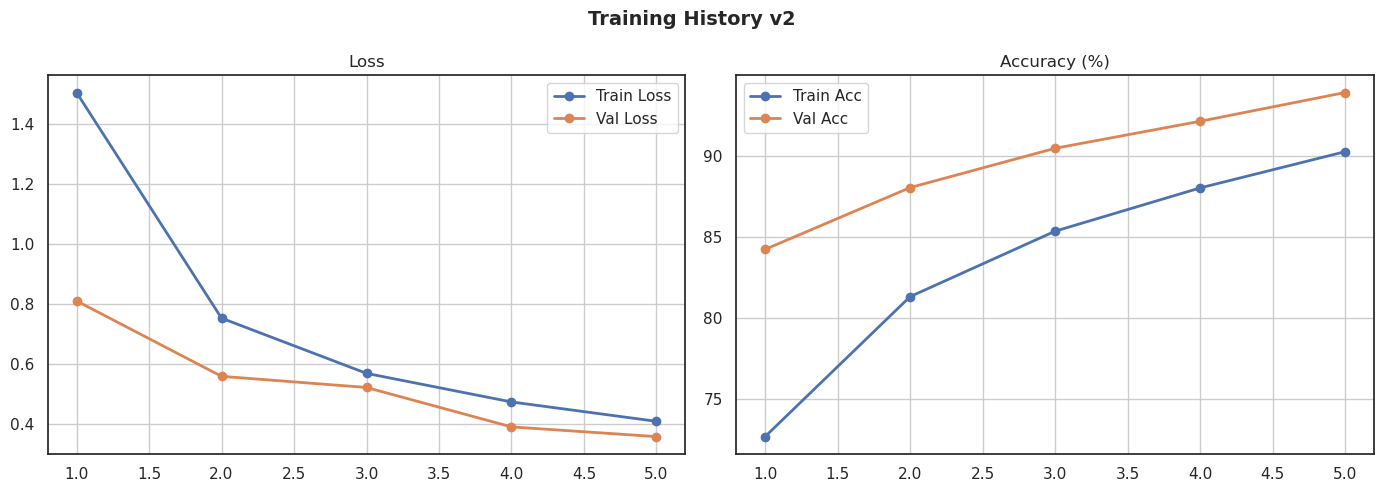


🎉 학습 완료! 최저 Val Loss: 0.3569


In [41]:
start_epoch = 0
best_loss   = float('inf')

# 1. Resume 로직 보정 (device 명시 및 예외 처리)
if args.resume:
    ckpt_path = os.path.join(args.checkpoint_dir, 'last.pth')
    if os.path.exists(ckpt_path):
        # 앞서 수정한 load_checkpoint는 device 인자를 받습니다.
        start_epoch, loaded_loss = load_checkpoint(model, optimizer, ckpt_path, device=device)
        best_loss = loaded_loss # Resume 시 best_loss도 복구
        start_epoch += 1
        print(f"   ▶ {start_epoch} 에폭부터 학습을 재개합니다.")
    else:
        print("체크포인트 파일이 없어 처음부터 학습을 시작합니다.")

history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}

print('\n' + '='*55)
print(f'  학습 시작  |  device: {device} | Seed: 42')
print(f'  epochs={args.epochs}, batch={args.batch_size}, img={args.img_size}, workers={args.num_workers}')
print('='*55 + '\n')

for epoch in range(start_epoch, args.epochs):
    t0 = time.time()

    # Train / Validate 단계
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, loss_fn, label_encoder, device, epoch)
    val_loss,   val_acc   = validate(model, val_loader, loss_fn, label_encoder, device, epoch)
    
    # 2. 스케줄러 업데이트 (ReduceLROnPlateau)
    scheduler.step(val_loss)

    # 기록 업데이트
    history['train_loss'].append(train_loss); history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss);     history['val_acc'].append(val_acc)

    elapsed = time.time() - t0
    
    # 3. 로그 출력 최적화
    print(f'\nEpoch {epoch+1}/{args.epochs} 완료 | 소요 시간: {elapsed:.0f}s')
    print(f'  [Train] Loss: {train_loss:.4f} Acc: {train_acc:.1f}%')
    print(f'  [Val]   Loss: {val_loss:.4f} Acc: {val_acc:.1f}%')

    # 체크포인트 저장 (last.pth)
    save_checkpoint(model, optimizer, epoch, val_loss, os.path.join(args.checkpoint_dir, 'last.pth'))
    
    # Best 모델 갱신 (best.pth)
    if val_loss < best_loss:
        best_loss = val_loss
        save_checkpoint(model, optimizer, epoch, val_loss, os.path.join(args.checkpoint_dir, 'best.pth'))
        print(f'  ★ Best model 갱신! (Val Loss: {val_loss:.4f})')
    
    print('-'*55)

# 4. 결과 저장 및 시각화
save_history_to_csv(history, args.checkpoint_dir)
plot_training_history(history, args.checkpoint_dir)
print(f'\n🎉 학습 완료! 최저 Val Loss: {best_loss:.4f}')

## 9. 모델 평가

## 혼동행렬 확인

Confusion Matrix 생성을 위해 검증 데이터 스캔 중...


100%|██████████| 468/468 [03:23<00:00,  2.29it/s]


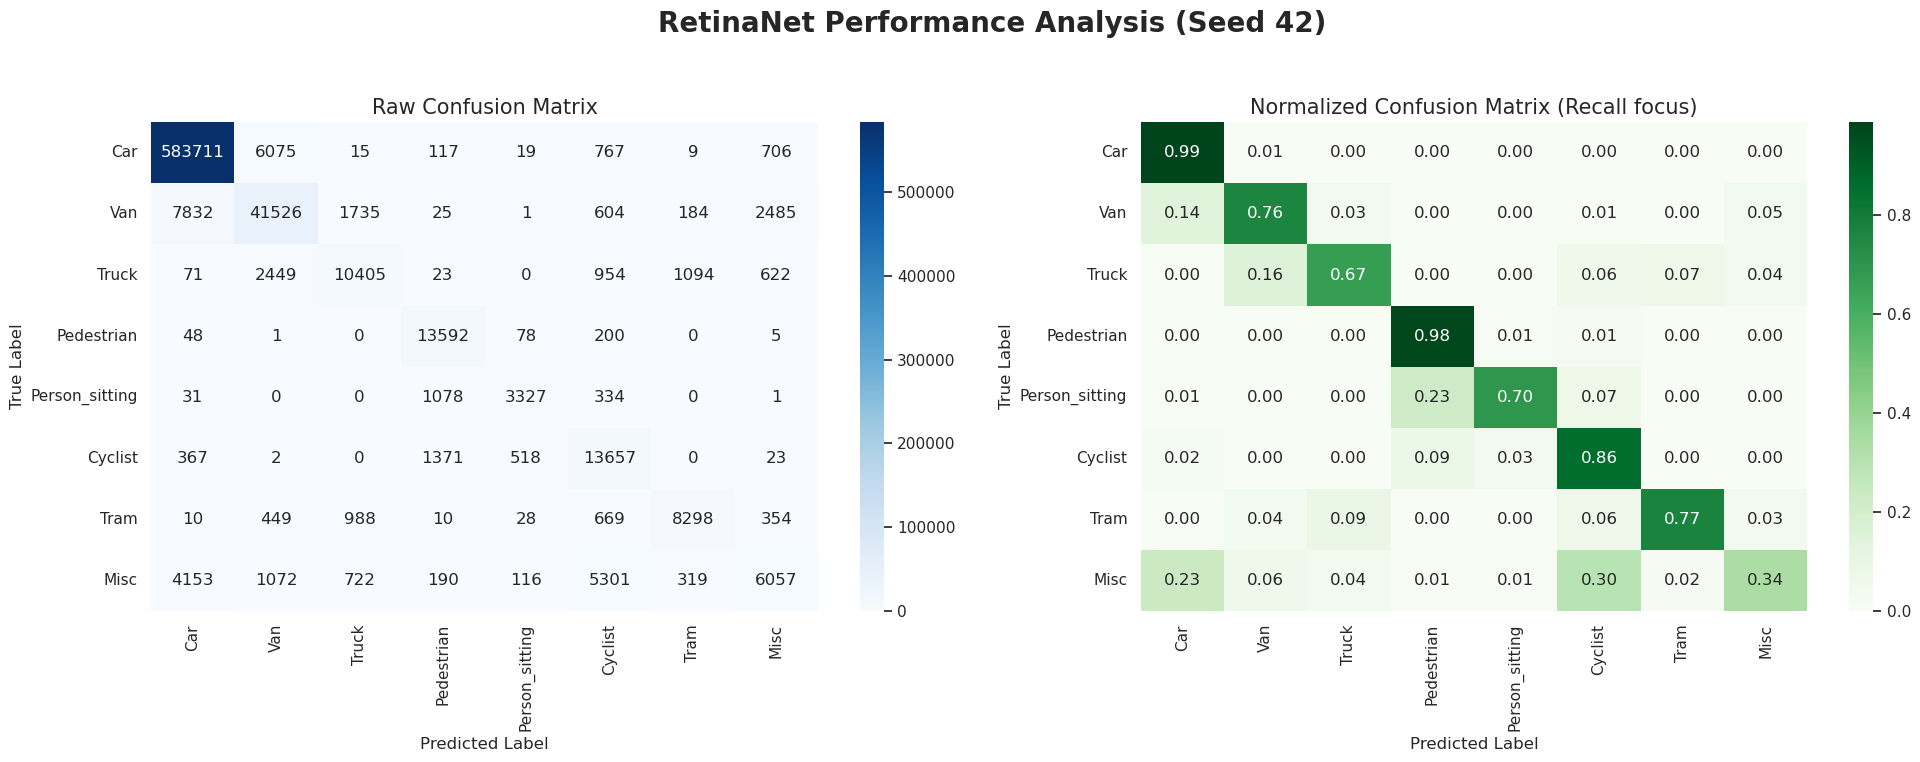

In [44]:
def plot_full_confusion_matrix(model, val_loader, device, num_classes=8, save_dir=None):
    model.eval()
    all_preds = []
    all_labels = []
    
    # KITTI 클래스 이름 (ID 순서와 일치해야 함)
    class_names = ['Car', 'Van', 'Truck', 'Pedestrian', 'Person_sitting', 'Cyclist', 'Tram', 'Misc']
    
    print("Confusion Matrix 생성을 위해 검증 데이터 스캔 중...")
    
    with torch.no_grad():
        for images_pil, targets_raw in tqdm(val_loader):
            # 1. 전처리 및 텐서화
            images_tensor = torch.stack([NORMALIZE(TO_TENSOR(img)) for img in images_pil]).to(device)
            boxes = [torch.tensor(t['boxes'], dtype=torch.float32) for t in targets_raw]
            labels = [torch.tensor(t['labels'], dtype=torch.int64) for t in targets_raw]
            
            # 2. 정답 인코딩 (Positive Anchor 추출용)
            encoded = label_encoder.encode_batch(images_tensor, boxes, labels)
            
            # 3. 모델 예측
            preds = model(images_tensor)
            
            # 4. 객체가 매칭된 Anchor(Positive) 위치만 필터링
            pos_mask = encoded[:, :, 4] >= 0
            if pos_mask.sum() > 0:
                pred_cls = torch.argmax(preds[:, :, 4:][pos_mask], -1).cpu().numpy()
                true_cls = encoded[:, :, 4].long()[pos_mask].cpu().numpy()
                
                all_preds.extend(pred_cls)
                all_labels.extend(true_cls)

    # Confusion Matrix 계산
    cm = confusion_matrix(all_labels, all_preds, labels=list(range(num_classes)))
    
    # 시각화 설정 (개수 버전 + 비율 버전 2개를 그림)
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # (1) Raw Count Matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=class_names, yticklabels=class_names)
    axes[0].set_title('Raw Confusion Matrix', fontsize=15)
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('True Label')

    # (2) Normalized Matrix (True Label 기준 비율)
    cm_norm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-8)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', ax=axes[1],
                xticklabels=class_names, yticklabels=class_names)
    axes[1].set_title('Normalized Confusion Matrix (Recall focus)', fontsize=15)
    axes[1].set_xlabel('Predicted Label')
    axes[1].set_ylabel('True Label')

    plt.suptitle('RetinaNet Performance Analysis (Seed 42)', fontsize=20, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    if save_dir:
        plt.savefig(os.path.join(save_dir, 'confusion_matrix.png'), dpi=150)
    plt.show()

plot_full_confusion_matrix(model, val_loader, device, save_dir=args.checkpoint_dir)

##### **주요 클래스별 성능 분석 (Normalized Confusion Matrix 기준)**

- Car (99%): 모델이 대다수의 자동차를 정확하게 탐지하고 있다.

- Pedestrian (98%): 이미지 내 실제 보행자를 보행자라고 잘 예측하는 성능이 뛰어나다.

- Cyclist (86%): 자전거 이용자 역시 비교적 높은 확률로 올바르게 인식하고 있다.

- Van (76%) & Truck (67%): 대형 차량군은 Car 클래스나 타 대형 차량 클래스와 어느 정도 혼동하는 경향이 보인다. 특히 Van의 14%가 Car로 오분류되었다.

- Person_sitting (70%): 앉아있는 사람의 23%를 서 있는 보행자로 분류했다. 두 클래스의 외형적 특징이 어느 정도 유사하기 때문인 것으로 보이는데, Go/Stop 판별 과제에는 이러한 오분류가 큰 영향을 미치지 못한다. 안전을 위해 우선 사람이 근접할 경우 무조건 멈춘다는 로직을 적용했기 때문이다.

- Misc (34%): 기타 객체에 대한 인식률이 가장 낮은데, Misc의 23%를 Car로, 30%를 Cyclist로 잘못 판단했다. 이는 모델이 탐지가 어려운 객체를 만났을 때 학습 데이터에서 클래스 수가 가장 많은 Car로 분류해버리는 특성이 있음을 보여준다.

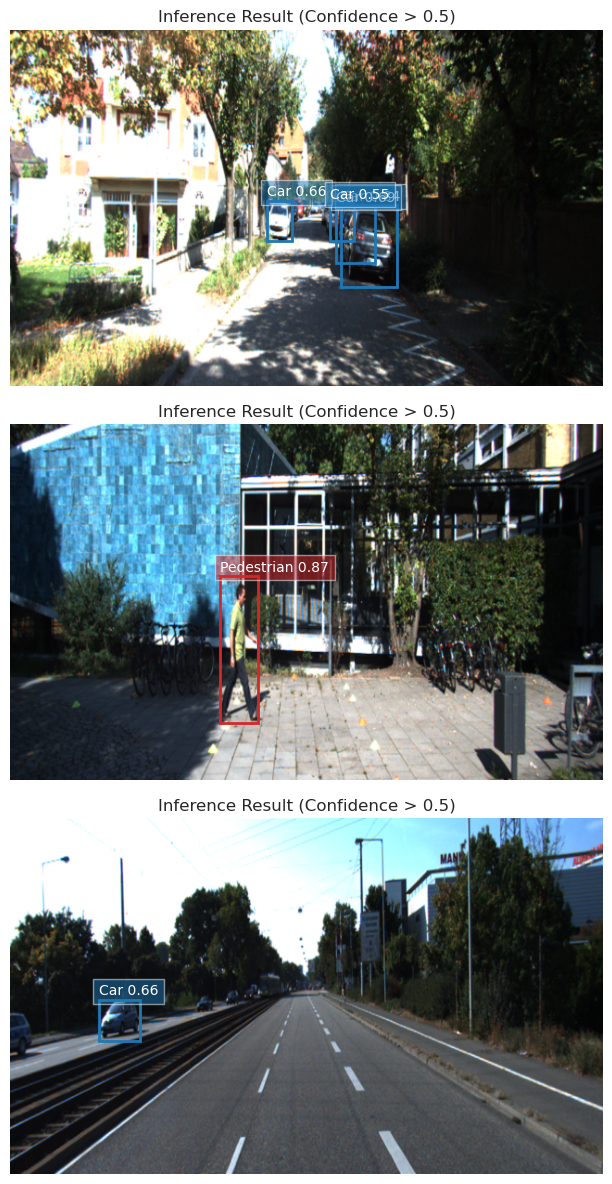

In [49]:
def decode_and_visualize(model, dataset, device, num_images=3, score_threshold=0.5, iou_threshold=0.4):
    model.eval()
    # KITTI 클래스 이름 및 색상
    class_names = ['Car', 'Van', 'Truck', 'Pedestrian', 'Person_sitting', 'Cyclist', 'Tram', 'Misc']
    colors = ['#1f77b4', '#aec7e8', '#2ca02c', '#d62728', '#ff7f0e', '#9467bd', '#bcbd22', '#7f7f7f']

    indices = random.sample(range(len(dataset)), num_images)
    # AnchorBox 클래스에서 전체 앵커를 미리 생성 (LabelEncoder와 동일한 H, W 사용)
    H, W = 384, 640 # args.img_size
    anchors = AnchorBox().get_anchors(H, W).to(device)
    
    # 박스 분산 값 (LabelEncoder와 동일)
    variances = torch.tensor([0.1, 0.1, 0.2, 0.2], device=device)

    fig, axes = plt.subplots(num_images, 1, figsize=(8, 4 * num_images))
    if num_images == 1: axes = [axes]

    with torch.no_grad():
        for i, idx in enumerate(indices):
            data = dataset[idx]
            image_pil = data['image']
            image_tensor = NORMALIZE(TO_TENSOR(image_pil)).unsqueeze(0).to(device)
            
            # 1. 모델 예측
            preds = model(image_tensor).squeeze(0) # [A, 4 + num_classes]
            
            # 2. 박스 디코딩 (RetinaNet Delta -> CXCYWH)
            reg_preds = preds[:, :4] * variances
            cx = reg_preds[:, 0] * anchors[:, 2] + anchors[:, 0]
            cy = reg_preds[:, 1] * anchors[:, 3] + anchors[:, 1]
            w = torch.exp(reg_preds[:, 2]) * anchors[:, 2]
            h = torch.exp(reg_preds[:, 3]) * anchors[:, 3]
            
            # CXCYWH -> X1Y1X2Y2
            x1, y1 = cx - w/2, cy - h/2
            x2, y2 = cx + w/2, cy + h/2
            boxes = torch.stack([x1, y1, x2, y2], dim=-1)

            # 3. 클래스 점수 및 NMS
            cls_scores = torch.sigmoid(preds[:, 4:])
            scores, labels = torch.max(cls_scores, dim=-1)
            
            # 임계값 필터링
            keep_idx = scores > score_threshold
            boxes, scores, labels = boxes[keep_idx], scores[keep_idx], labels[keep_idx]
            
            # NMS 적용 (중복 박스 제거)
            if len(boxes) > 0:
                nms_idx = nms(boxes, scores, iou_threshold)
                boxes, scores, labels = boxes[nms_idx], scores[nms_idx], labels[nms_idx]

            # 4. 그리기
            axes[i].imshow(image_pil)
            for box, score, label in zip(boxes, scores, labels):
                bx, by, bw, bh = box[0].item(), box[1].item(), (box[2]-box[0]).item(), (box[3]-box[1]).item()
                rect = mpatches.Rectangle((bx, by), bw, bh, linewidth=2, edgecolor=colors[label], facecolor='none')
                axes[i].add_patch(rect)
                axes[i].text(bx, by-5, f"{class_names[label]} {score:.2f}", 
                             color='white', fontsize=10, bbox=dict(facecolor=colors[label], alpha=0.5))
            
            axes[i].set_title(f"Inference Result (Confidence > {score_threshold})")
            axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# 실행 (best_model_v2.pth가 로드된 상태여야 함)
decode_and_visualize(model, val_loader.dataset, device, num_images=3)

앞서 혼동행렬로 모델의 분류 성능을 확인했다. 이번에는 추론 성능을 실제 이미지로 확인한다.

- 두 번째 이미지에서 주변에 자전거들이 복잡하게 섞여 있는 환경임에도 불구하고 보행자만 깔끔하게 분리해 0.87이라는 높은 신뢰도(Confidence)로 잡아냈다.

- 첫 번째와 세 번째 이미지에서 멀리 떨어져 작게 보이는 차량들도 놓치지 않고 클래스를 Car로 정확히 분류하고 위치를 바운딩 박스로 표시했다.

### 테스트셋 평가

self_drive_assist 함수의 경우 모델 저장 경로와 이미지 해상도를 수정하여 사용한다.

In [21]:
# 학습된 모델 경로
CHECKPOINT_V2_PATH = os.path.join(os.getenv('HOME'), 'work/object_detection/checkpoints_v2/best.pth')

# 학습 시 사용한 클래스 이름과 정확히 일치해야 함
CLASS_NAMES = ['Car', 'Van', 'Truck', 'Pedestrian', 'Person_sitting', 'Cyclist', 'Tram', 'Misc']
PERSON_CLASSES = {'Pedestrian', 'Person_sitting', 'Cyclist'}

def self_drive_assist(img_path: str, size_limit: int = 300) -> str:
    """
    자율주행 보조 판단 함수 (v2 최적화 버전)

    수정 사항:
    1. img_size를 v2 학습 규격인 (384, 640)으로 수정
    2. CHECKPOINT_V2_PATH를 명시적으로 로드하도록 변경
    """
    # 1. 파일 존재 확인
    if not os.path.exists(img_path):
        print(f"[WARN] 이미지 파일 없음: {img_path} → Stop (안전 우선)")
        return "Stop"

    try:
        # 2. 이미지 로드 및 크기 정보 획득
        image = Image.open(img_path).convert('RGB')
        original_width, original_height = image.size
        
        # ★ 중요: v2 학습 시 사용한 해상도 (H, W) = (384, 640)
        input_size = (384, 640)  
        
        # 원본 대비 스케일 계산 (판단 로직에서 원본 좌표 복원을 위해 필요)
        scale_w = input_size[1] / original_width
        scale_h = input_size[0] / original_height

        # 3. 전처리 (학습 시와 동일한 파이프라인)
        transform = transforms.Compose([
            transforms.Resize(input_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std =[0.229, 0.224, 0.225])
        ])
        
        # 4. 모델 로드 (캐싱된 모델 사용, 경로만 v2로 전달)
        # _get_model 함수가 checkpoint_path 인자를 받도록 설계되어 있어야 함
        model, decoder, device = _get_model(checkpoint_path=CHECKPOINT_V2_PATH)
        image_tensor = transform(image).unsqueeze(0).to(device)

        # 5. 추론 및 디코딩
        with torch.no_grad():
            predictions = model(image_tensor)
            # decoder는 (image_tensor, predictions)를 받아 (boxes, scores, labels) 리스트 반환
            decoded = decoder(image_tensor, predictions)

        # 첫 번째 배치 결과 추출
        boxes, scores, classes = decoded[0]

        # 탐지 결과가 전혀 없는 경우
        if len(boxes) == 0:
            return "Go"

        boxes   = boxes.cpu().numpy()
        classes = classes.cpu().numpy()
        scores  = scores.cpu().numpy()

        # 6. 판단 로직 (Confidence Threshold 0.5 가정)
        for i, (box, cls_id) in enumerate(zip(boxes, classes)):
            if scores[i] < 0.5: continue # 신뢰도 낮은 결과 무시
            
            class_name = CLASS_NAMES[cls_id]

            # [조건 1] 사람 클래스 탐지 시 즉시 Stop
            if class_name in PERSON_CLASSES:
                # print(f"[INFO] {class_name} 탐지됨 (Score: {scores[i]:.2f})")
                return "Stop"

            # [조건 2] 차량 박스 크기가 size_limit 이상일 때 Stop
            x1, y1, x2, y2 = box
            # 모델 입력 좌표(640) -> 원본 이미지 좌표로 복원
            real_w = (x2 - x1) / scale_w
            real_h = (y2 - y1) / scale_h
            
            if real_w >= size_limit or real_h >= size_limit:
                # print(f"[INFO] 큰 객체 탐지: {class_name} ({real_w:.1f}x{real_h:.1f})")
                return "Stop"

        return "Go"

    except Exception as e:
        print(f"[ERROR] 처리 중 오류 발생: {e} → Stop (안전 우선)")
        return "Stop"

In [22]:
# 단일 이미지 테스트
result_v2 = self_drive_assist(temp_img_path)
print(f"\n판단 결과: [{result_v2}]")


판단 결과: [Go]


In [23]:
score_v2, results_v2 = test_system(self_drive_assist)

파일                 정답       예측       결과
stop_1.png         Stop     Go       ❌
stop_2.png         Stop     Go       ❌
stop_3.png         Stop     Stop     ✅
stop_4.png         Stop     Stop     ✅
stop_5.png         Stop     Stop     ✅
go_1.png           Go       Go       ✅
go_2.png           Go       Go       ✅
go_3.png           Go       Go       ✅
go_4.png           Go       Go       ✅
go_5.png           Go       Go       ✅

🏆 최종 점수: 80점 / 100점


baseline 모델이 기록한 60점보다 높은 80점이다. 이번에도 맞추지 못한 `stop_1`과 `stop_2` 테스트 이미지를 확인한다.

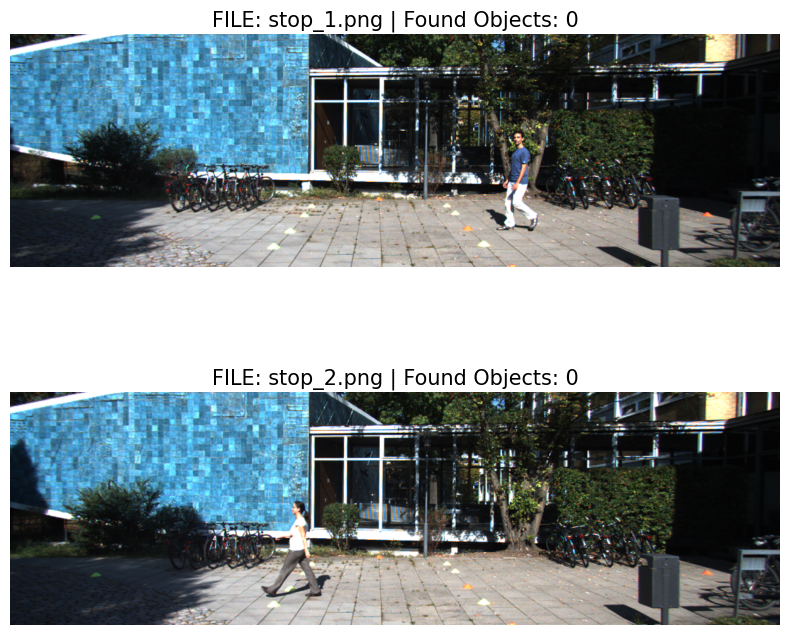

In [29]:
# ── [설정] 경로 및 상수 ──────────────────────────────────────────
CLASS_NAMES = ['Car', 'Van', 'Truck', 'Pedestrian', 'Person_sitting', 'Cyclist', 'Tram', 'Misc']
COLORS = ['#1f77b4', '#aec7e8', '#2ca02c', '#d62728', '#ff7f0e', '#9467bd', '#bcbd22', '#7f7f7f']

def debug_visualize_files(file_list, score_thresh=0.1, size_limit=200):
    """
    특정 이미지 파일들에 대해 모델이 탐지한 모든 객체를 시각화
    score_thresh를 낮게 설정하여 '아슬아슬하게 놓친' 객체까지 잡아낸다.
    """
    # 1. 모델 로드 (v2)
    model, decoder, device = _get_model(checkpoint_path=CHECKPOINT_V2_PATH)
    model.eval()
    
    # 2. 전처리 설정
    input_size = (384, 640)
    transform = transforms.Compose([
        transforms.Resize(input_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    fig, axes = plt.subplots(len(file_list), 1, figsize=(8, 4 * len(file_list)))
    if len(file_list) == 1: axes = [axes]

    for i, file_name in enumerate(file_list):
        img_path = os.path.join(DATA_DIR, file_name)
        if not os.path.exists(img_path):
            print(f"파일 없음: {img_path}")
            continue

        # 이미지 로드 및 추론
        image_pil = Image.open(img_path).convert('RGB')
        orig_w, orig_h = image_pil.size
        image_tensor = transform(image_pil).unsqueeze(0).to(device)
        
        with torch.no_grad():
            predictions = model(image_tensor)
            # decoder 내부에서 NMS와 Score Filtering이 일어납니다. 
            # 만약 decoder가 threshold를 인자로 받는다면 넘겨주는 것이 좋습니다.
            decoded = decoder(image_tensor, predictions)

        boxes, scores, labels = decoded[0]
        
        axes[i].imshow(image_pil)
        axes[i].set_title(f"FILE: {file_name} | Found Objects: {len(boxes)}", fontsize=15)

        scale_w = input_size[1] / orig_w
        scale_h = input_size[0] / orig_h

        for box, score, label in zip(boxes, scores, labels):
            # 필터링 수치 확인용 로그
            if score < score_thresh: continue
            
            x1, y1, x2, y2 = box.cpu().numpy()
            
            # 원본 이미지 좌표로 복원
            real_w = (x2 - x1) / scale_w
            real_h = (y2 - y1) / scale_h
            
            # 그리기
            rect = mpatches.Rectangle((x1/scale_w, y1/scale_h), real_w, real_h, 
                                     linewidth=2, edgecolor=COLORS[label], facecolor='none')
            axes[i].add_patch(rect)
            
            # 정보 표시 (클래스명, 스코어, 실제 가로길이)
            label_text = f"{CLASS_NAMES[label]} {score:.2f} (w:{real_w:.0f})"
            axes[i].text(x1/scale_w, (y1/scale_h)-10, label_text, 
                         color='white', fontsize=12, bbox=dict(facecolor=COLORS[label], alpha=0.7))

        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# 실행
difficult_test_files = ['stop_1.png', 'stop_2.png']
debug_visualize_files(difficult_test_files, score_thresh=0.05)

`stop_1`과 `stop_2` 테스트 이미지 모두 화면 하단의 보행자 객체를 포함한다. 위 모델이 추론한 객체 이미지와 비교했을 때, 테스트 이미지 내 보행자의 너비, 높이, 비율 등이 달라보인다. 만약 모델에 입력되는 이미지 크기가 학습 시와 다른 비율로 늘려졌다면, 사람의 특징(세로로 긴 형태)이 깨지면서 인식이 안 되었을 가능성이 높다.

그러므로 테스트 데이터 이미지 크기를 조정한다. 단순히 `Resize((384, 640))`를 하면 이미지가 찌그러지므로, 이미지의 비율을 유지하면서 남는 공간을 검은색으로 채우는 **Letterbox 방식 (또는 padding 추가)** 을 사용하여 보행자의 특징을 보존되도록 한다.

In [36]:
def self_drive_assist_v3(img_path: str, size_limit: int = 150) -> str:
    if not os.path.exists(img_path): return "Stop"

    try:
        image = Image.open(img_path).convert('RGB')
        orig_w, orig_h = image.size
        
        # 1. 비율 유지 리사이즈 (가로를 640으로 맞추면 세로는 약 192가 됨)
        # 억지로 384로 늘리지 않고 비율만 맞춥니다.
        target_w = 640
        target_h = int(orig_h * (target_w / orig_w))
        
        # 2. 전처리: 비율 유지 리사이즈 + 부족한 부분 검은색 패딩(384x640 채우기)
        transform = transforms.Compose([
            transforms.Resize((target_h, target_w)),
            transforms.Pad((0, 0, 0, 384 - target_h)), # 아래쪽 남는 공간 채움
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        
        model, decoder, device = _get_model(checkpoint_path=CHECKPOINT_V2_PATH)
        image_tensor = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            predictions = model(image_tensor)
            decoded = decoder(image_tensor, predictions)

        boxes, scores, classes = decoded[0]

        # 3. 판단 로직: 임계값을 낮춰서 아주 작은 기척이라도 잡습니다.
        for i, (box, cls_id) in enumerate(zip(boxes, classes)):
            if scores[i] < 0.25: continue # 신뢰도 기준 하향
            
            class_name = CLASS_NAMES[cls_id]
            
            # [조건 1] 사람 클래스면 즉시 Stop
            if class_name in PERSON_CLASSES:
                return "Stop"

            # [조건 2] 차량 크기 판단 (비율이 유지되었으므로 size_limit도 낮게 조정)
            x1, y1, x2, y2 = box.cpu().numpy()
            if (x2 - x1) >= size_limit or (y2 - y1) >= 100:
                return "Stop"

        return "Go"
    except Exception as e:
        print(f"Error: {e}")
        return "Stop"

In [37]:
score_v3, results_v3 = test_system(self_drive_assist_v3)

파일                 정답       예측       결과
stop_1.png         Stop     Stop     ✅
stop_2.png         Stop     Stop     ✅
stop_3.png         Stop     Stop     ✅
stop_4.png         Stop     Stop     ✅
stop_5.png         Stop     Stop     ✅
go_1.png           Go       Go       ✅
go_2.png           Go       Go       ✅
go_3.png           Go       Go       ✅
go_4.png           Go       Go       ✅
go_5.png           Go       Go       ✅

🏆 최종 점수: 100점 / 100점


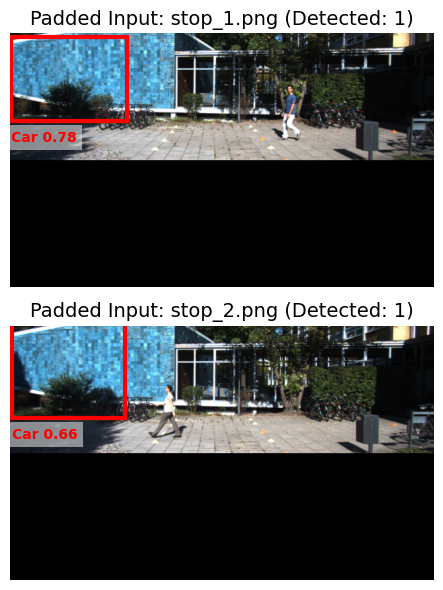

In [42]:
def visualize_padded_results(file_list):
    """패딩(Letterbox) 전처리가 적용된 모델의 입력 상태와 탐지 결과 시각화"""
    model, decoder, device = _get_model(checkpoint_path=CHECKPOINT_V2_PATH)
    model.eval()
    
    fig, axes = plt.subplots(len(file_list), 1, figsize=(6, 3 * len(file_list)))
    if len(file_list) == 1: axes = [axes]

    for i, file_name in enumerate(file_list):
        img_path = os.path.join(DATA_DIR, file_name)
        image = Image.open(img_path).convert('RGB')
        orig_w, orig_h = image.size
        
        # 1. 100점 로직의 패딩 전처리 재현
        target_w = 640
        target_h = int(orig_h * (target_w / orig_w))
        
        transform = transforms.Compose([
            transforms.Resize((target_h, target_w)),
            transforms.Pad((0, 0, 0, 384 - target_h)), # 아래쪽 검은색 패딩 추가
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        
        input_tensor = transform(image).unsqueeze(0).to(device)
        
        # 2. 모델 추론
        with torch.no_grad():
            predictions = model(input_tensor)
            decoded = decoder(input_tensor, predictions)
        
        boxes, scores, classes = decoded[0]
        
        # 3. 시각화를 위해 텐서를 이미지로 역변환 (Normalize 해제)
        disp_img = input_tensor[0].cpu().permute(1, 2, 0).numpy()
        disp_img = disp_img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        disp_img = np.clip(disp_img, 0, 1)

        axes[i].imshow(disp_img)
        axes[i].set_title(f"Padded Input: {file_name} (Detected: {len(boxes)})", fontsize=14)

        # 4. 박스 그리기 (패딩된 좌표계 그대로 사용)
        for box, score, cls_id in zip(boxes, scores, classes):
            if score < 0.25: continue
            x1, y1, x2, y2 = box.cpu().numpy()
            rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color='red', linewidth=3)
            axes[i].add_patch(rect)
            axes[i].text(
                x1,                # x 좌표는 그대로 유지
                y2 + 15,           # y1(상단) 대신 y2(하단)를 사용하고, 아래로 15px 정도 여백을 줌
                f"{CLASS_NAMES[cls_id]} {score:.2f}", 
                color='red', 
                fontweight='bold', 
                verticalalignment='top', # 텍스트의 기준점을 위쪽으로 설정하여 y2 아래로 정렬되게 함
                bbox=dict(facecolor='white', alpha=0.5, edgecolor='none')
            )

        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# 특히 문제였던 stop_1, stop_2 확인
visualize_padded_results(['stop_1.png', 'stop_2.png'])

Padding 도입 후 수치상으로는 100점을 달성했으나, 탐지한 내용을 이미지로 확인하니 그저 운이 좋았음을 알 수 있었다. 이미지 내 보행자를 찾은 것이 아니라, 식물을 차로 오인하고 그 크기가 stop size limit을 넘었기 때문에 발생한 케이스이다.

패딩을 추가할 때 이미지를 아래로 밀고 검은색 여백을 넣으면서, 모델이 학습할 때 보았던 도로 위 차량과 보도 위 식물의 위치와 형태가 비슷해보이는 착시 현상이 일어난 것으로 추정된다.

## 회고

- 사람은 예시 몇 장만 보고도 금방 구분하는 객체 클래스와 위치를 모델은 5단계가 넘는 학습 과정을 거치고도 어려워하다니 인간 두뇌가 얼마나 대단한지 느꼈다.

- train 성능보다 val 성능이 더 좋은 현상은 왜 그런지 아직 고민 중이다...

- 보행자나 자동차처럼 관심 대상인 객체 외에 건물이나 보도를 무시할 수 있도록 한다면 Go/Stop 판별력이 더 좋아질 것 같다는 생각을 했다. 찾아보니 Region of Interest 라는 기법이 있다고 하는데, 수동 설정은 시간 자원을 생각했을 때 어림도 없는 일이다. 자동 설정은 다른 모델을 또 배워야 해서 아직 시도하지 못했다.

- `num_workers`와 `batch size`를 조정해 메모리 포화를 아슬아슬하게 넘나들며 학습 시간을 절반 정도로 줄였다. 한정된 자원으로 최적화를 진행하는 방법을 더 연구해야겠다는 생각이 들었다.